# DD2 + vMIT — general framework for the first-order deconfinement transition

A hadronic EOS (**DD2**, a density-dependent relativistic mean field) and a quark EOS
(**vMIT**, a vector-enhanced bag model) joined across a first-order deconfinement
phase transition, with the character of that transition controlled by a single
continuous parameter **η**.

**What η means.** The hadronic (*H*) and quark (*Q*) phases coexist in the mixed
phase with a *quasi-permeable* interface for charged leptons: in the vicinity of the
interface the two phases exchange charged leptons, which then help neutralize
electric charge across both phases, while regions farther away remain effectively
locally charge neutral. Charge neutrality is therefore realized *partly locally* and
*partly globally*, and η ∈ [0,1] measures the fraction of charged leptons that
enforce local charge neutrality (**LCN**) separately in each phase; the remaining
fraction 1−η participates only in global charge neutrality (**GCN**).

| η | construction | behaviour through the mixed phase |
|---|---|---|
| 0 | **Gibbs (GC)** | baryon number *and* electric charge are conserved globally; only the volume average is neutral and the pressure varies continuously across the mixed phase |
| 1 | **Maxwell (MC)** | baryon number is the only globally conserved charge and neutrality is imposed locally in each phase; the pressure remains constant and the window collapses to a density jump |
| in between | — | finite-size effects are *not* included microscopically; their net impact is emulated by tuning the balance between local and global neutrality through η |

An equivalent picture is that of pure-phase "lumps" forming in the coexistence
region. If their characteristic size is much larger than the Debye screening length,
charged leptons are effectively tied to individual lumps and charge neutrality is
local — roughly, the σ → ∞ limit; if it is much smaller, they experience an averaged
background and neutrality becomes purely global (σ → 0). Intermediate sizes
correspond to 0 < η < 1.

**How a density is classified.** The quark volume fraction χ ≡ V_Q/(V_H + V_Q) comes
out of the solve and is *not* clamped: **χ ≤ 0 → pure hadronic, χ ≥ 1 → pure quark,
0 < χ < 1 → mixed phase.** The table builder locates the two χ crossings first and
then solves the expensive mixed system only between them.

**The two sound speeds.** A first-order transition has two, and the gap between
them is the clearest single picture of what η does:

| | what is free | behaviour in the window |
|---|---|---|
| **c_eq² = dP/dε** | χ readjusts | dips at η=0, **collapses to 0** at η=1 |
| **c_ad² (frozen)** | χ held fixed | stays finite at every η |

c_eq is what enters the TOV equations; c_ad is what a fast disturbance sees.
Section III.4 plots both.

---
**Layout**
- **Part I** — imports, the parameter-space funnel, then every knob in one cell.
- **Part II** — pure phases, the mixed tables, TOV, and a parameter scan.
- **Part III** — plots, all defined here in the notebook.

**Start here if you are choosing parameters:** run Part I only. Section I.2 is a
staged funnel over (nuclear-matter parameters × hyperon and Δ potentials × B^1/4,
a, m_s × η) that reports which combinations land in a target M_max and R(1.4) band
and, for each, whether the centre of the star is hadronic, mixed or pure quark. It
ends by printing the recipe for the best one, ready to paste into I.3 before Part II
is run at full resolution. Section II.4 then maps the (B^1/4, a) plane of that one
choice as a picture.

# Part I — setup

## I.1 Imports

Imports the repository clone when the notebook sits inside one — the root is found by
walking up for `pyproject.toml` — and falls back to installing the package from GitHub
only when it does not, so a stale copy in `site-packages` can never shadow the working
tree. The line printed at the end says which copy was actually loaded.


In [ ]:
import sys
import time
import subprocess
from pathlib import Path

ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "pyproject.toml").is_file() and (p / "eos").is_dir()), None)
if ROOT is not None:
    sys.path.insert(0, str(ROOT))
    for _m in [m for m in sys.modules if m == "eos" or m.startswith("eos.")]:
        del sys.modules[_m]

try:
    import eos.mixed
except ImportError:      
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--no-deps",
                           "--quiet",
                           "git+https://github.com/guerrinimirco/eos.git"])
    import eos.mixed

import numpy as np
import matplotlib.pyplot as plt
from dataclasses import replace
from collections import Counter, defaultdict
from joblib import Parallel, delayed

from eos.dd2 import Parametrization, SpeciesFlags, hadronic_row, compute_nmp
from eos.dd2.solver import sweep_beta_eq_octet, sweep_octet
from eos.vmit.parameters import get_vmit_custom
from eos.vmit.eos import solve_vmit_beta_eq, solve_vmit_fixed_yc
from eos.tov.solver import find_mmax_precise
from eos.tov.rotating import (kepler_sequence, rotating_grid,
                              GRID_COLUMNS, KEPLER_COLUMNS)
from eos.tov.rns_backend import have_rns
from eos.mixed import (
    beta_eq_neutrinoless, fixed_YC,
    MixedTableSpec, build_mixed_table, build_mixed_eos_table,
    mass_radius_mixed, save_table, load_table, export_csv,
    sweep_mixed, sound_speed_eq, frozen_along,
    scan_parameters, scan_hadronic, grid_samples,
    build_parametrization, NMP_KEYS,
)

from eos.general.figure_style import (
    set_global_style, paper_grid, save_figure, particle_style,
    LABELS, STANDARD_COLORS,
)
from eos.general.observational_constraints import (
    add_observational_constraints, add_tidal_constraints)

set_global_style()

OUT = Path("eos_tables_DD2vMIT")
OUT.mkdir(exist_ok=True)
FIG_DIR = OUT / "figures"
FIG_DIR.mkdir(exist_ok=True)
print("eos imported from:", Path(eos.__file__).parent)

## I.2 Parameter-space funnel — which parameters give the star you asked for?

One cell, four questions, asked in the order that fails cheapest. Each stage runs
only on what survived the one before, so the expensive mixed-phase solves are never
spent on parameters that were already ruled out.

| stage | question | cost per sample |
|---|---|---|
| **1** | which nuclear-matter parameters have a DD-RMF realisation at all? | milliseconds |
| **2** | which of those, crossed with the hyperon and Δ potentials, give a hadronic branch near the target band? | ~1 s |
| **3** | which of those, crossed with the quark parameters, give M_max and R(1.4) in the target band — at how many η, and **where does the centre of the star actually sit**? | ~2–3 s |

**The answer stage 3 gives is a phase, not a yes/no.** A transition existing in the
equation of state and a transition being *realised inside a star* are different
statements: the window can open at a density no stable star reaches. Every
combination is therefore labelled by where the central baryon density of the
maximum-mass star falls:

| `core_phase` | meaning | is it a hybrid star? |
|---|---|---|
| `none` | no window on this grid | no — pure hadronic, judged on the stage-2 hadronic M_max and R(1.4) |
| `H` | a window exists but n_Bc < n_onset | no — the transition is above every stable star |
| `mix` | n_onset ≤ n_Bc < n_offset | yes — a mixed-phase core |
| `Q` | n_Bc ≥ n_offset | yes — a genuine pure-quark core |

**Which parameters can actually be varied.** `L_sym` is free — the isovector
inversion is near-analytic and converges across 30–100 MeV. **`K_sat` is not**: the
isoscalar system is closed by a cross-constraint that ties `K_sat` to `Q_sat`, so
moving `K_sat` alone leaves a residual that grows away from the DD2 value (~3e-2 at
240 MeV against a 2e-2 gate, 0.2 by 220 MeV). Stage 1 reports it as
`inversion_failed`, which is a statement about the DD2 functional form, not a solver
defect. The `K_sat` axis is kept below precisely so you can see that.

The hadronic *sector* knobs are all free and matter far more than the NMP do, because
they set how soft the hadronic branch becomes: `x_wD` alone moves the viable fraction
by a factor of ~4, while `U_Lambda` and `U_Xi` barely move it once the transition
sits below the hyperon threshold. `from_delta_potential` restricts `U_Delta` to the
literature range [-100, -50] MeV.

**The stage-2 cut is deliberately soft.** A hadronic branch under 2 M_sun is not
disqualifying — quark matter with a > 0 stiffens the star and routinely lifts it back
above two solar masses — so stage 2 reports every sample and drops only those under a
loose floor. `sweep_truncated` is kept for the same reason: the hadronic branch only
has to reach the transition *onset*, not the top of the grid, and a Δ model driving
the effective mass to zero at high density is expected physics.

**A third stage-3 outcome, and with hyperons and Δ on it is a common one:
`eos_unphysical`.** The χ=0 crossing the window locator finds can be spurious at a
low bag constant — the mixed branch it locks onto sits at a *lower* pressure than the
hadronic branch at the same density, so it is not the favoured state, and the
stitched table steps *down* at the onset. Integrating that returns confident nonsense
(maximum masses in the hundreds of solar masses), so P monotonicity and 0 ≤ c_s² ≤ 1
are checked **before** the TOV run. Those rejections are the scan working.

The funnel runs on the coarse `FUNNEL_GRID`; it is reconnaissance. Re-run Part II on
the winning recipe printed at the end into I.3, then run Part II at full `NB`.

The stages are separate cells on purpose: tightening `M_MAX_RANGE` or `R14_RANGE` and
re-running the last two cells is instantaneous, where re-running the whole funnel
is minutes.

In [ ]:
from eos.mixed import scan_point

#: The keys `build_parametrization` understands. A finished scan row carries
#: results and string columns alongside them, and only these may be fed back in.
PAR_KEYS = NMP_KEYS + ("U_Lambda", "U_Sigma", "U_Xi", "U_Delta", "x_wD", "x_rD")

# ---- what counts as an acceptable star ------------------------------------
# The band the FINAL star must land in. Stage 3 tests these.
M_MAX_RANGE = (2.0, 2.6)          # M_sun
R14_RANGE = (11.5, 13.5)          # km, radius at M = 1.4 M_sun

# The stage-2 pre-filter on the PURE HADRONIC branch. Deliberately looser than
# the target band: quark matter changes both numbers, so a hard cut here throws
# away hybrid stars that would have qualified. A sample whose hadronic TOV did
# not integrate at all is kept — nan is "unknown", not "failed".
HAD_M_MIN = 1.6                   # M_sun, soft floor (NOT M_MAX_RANGE[0])
HAD_R14_RANGE = (10.0, 15.0)      # km, soft band

# ---- axes -----------------------------------------------------------------
# Independent of the PAR / FLAGS / VMIT chosen in I.3: this section builds its
# own parametrizations from nuclear-matter parameters, with hyperons and Delta
# isobars switched on regardless of what FLAGS says.
FUNNEL_FLAGS = SpeciesFlags(hyperons=True, deltas=True, muons=True,
                            phi_field=True, photons=True)
NUCLEON_FLAGS = SpeciesFlags(hyperons=False, deltas=False, muons=True,
                             phi_field=False, photons=True)

# ---- stage-1 axes: K_sat and Q_sat on a plain rectangular grid ------------
# Both are swept independently and widely, which is worth a word because it
# contradicts what a single-seeded inversion appears to say.
#
# The isoscalar sector has six free couplings — Gamma_sigma, b_sigma, c_sigma
# and their omega counterparts, since d_i and a_i are fixed by f_i''(0) = 0 and
# f_i(1) = 1 — matched to six conditions: P(n_sat) = 0, E_sat, m*/m, K_sat,
# Q_sat and the closing cross-constraint f_sigma''(1) = f_omega''(1). A square
# system, so the freedom is genuinely limited. But the set that a solve seeded
# from the published DD2 couplings can REACH is much smaller than the set that
# exists, and it traces a narrow band through DD2's own (K_sat, Q_sat) that is
# easy to mistake for a physical constraint curve. On a 187-cell grid over
# K_sat = 200-300 and Q_sat = 0-400 MeV, the single seed inverts 7 cells;
# 32 restarts invert 68 and 64 restarts invert 115, still without saturating.
#
# `invert_nmp` now restarts on a miss by default, so stage 1 reports the second
# number rather than the first — but a miss costs n_restarts solves, which is
# why stage 1 is no longer free and why the grid below is a few dozen cells
# rather than a few hundred.
SCAN_K_SAT = np.arange(210.0, 291.0, 20.0)        # MeV
# Widened from 250-350 because m*/m is now an axis: the isoscalar
# cross-constraint ties the two together (I.4 measures this), so an m*/m away
# from 0.5625 only inverts at a Q_sat away from 300, and a narrow Q_sat grid
# would report the new axis as almost entirely `inversion_failed`.
SCAN_Q_SAT = np.arange(250.0, 476.0, 50.0)        # MeV, independent of K_sat
SCAN_L_SYM = [30.0, 50.0, 70.0, 90.0]             # free over 30-100
# The Dirac effective mass at saturation, m*/m. It is on this axis because it
# is the isoscalar knob with real leverage and holding it fixed silently pins
# the high-density behaviour: it sets the scalar coupling strength, hence how
# fast the scalar field saturates, hence the stiffness above ~2 n_sat AND the
# density at which every hyperon and Delta threshold opens. I.2b measures that
# against the other held-fixed parameters. The range is the span the DD-RMF
# literature actually uses; outside ~0.50-0.65 the inversion stops converging.
SCAN_M_EFF = [0.52, 0.5625, 0.60]                 # m*/m at saturation

# How many stage-1 survivors reach the expensive stages. The grid above is wide
# so the feasible region is visible; carrying every cell of it into stage 3
# would multiply that stage's cost by the number of survivors. They are thinned
# evenly, so what goes forward still spans the region rather than clustering at
# one corner of it.
MAX_NMP = 10

# ---- stage-2 axes: spend the budget where the sensitivity is ---------------
# It is very uneven. x_wD alone moves the viable fraction by a factor of ~4 and
# U_Delta sets how soft the branch becomes, while U_Lambda and U_Xi barely move
# anything once the transition sits below the hyperon threshold — so those two
# are held at one value each and the freed factor of four goes to the axes that
# matter. U_Sigma is the least constrained hyperon potential (repulsive, but by
# how much is genuinely open), so it gets an axis rather than a default.
SCAN_U_LAMBDA = [-30.0,-25]           # MeV, hyperon potentials in SNM at n_sat
SCAN_U_SIGMA = [0.0, 30.0]
SCAN_U_XI = [-22.0,-10]
SCAN_U_DELTA = [-100.0, -50.0]   # from_delta_potential limits
SCAN_X_WD = [0.9, 1.2]  # Delta vector ratio x_omegaDelta
SCAN_X_RD = [1.0]                 # x_rhoDelta; the isovector ratio moves least

# a and B^1/4 both raise the onset density, so the viable combinations sit on
# an anticorrelated ridge: a = 0.20 wants B^1/4 ~ 160-180, a = 0.10
# wants ~190-200. A rectangular grid over the pair therefore spends most of its
# cells off that ridge, which is worth knowing when reading the reject count and
# is why both axes are swept wide rather than finely. Outside 0.05 <= a <= 0.20
# nothing survives: a = 0 leaves the quark phase too soft to reach 2 M_sun, and
# by a = 0.25 the ordered window is gone for every B^1/4 from 120 to 200 MeV.
SCAN2_B4 = [160.0, 170.0, 180.0]   # MeV
SCAN2_A = [0., 0.2, 0.4,  0.6,  0.8]               # fm^2
SCAN2_MS = [50, 150.0]                # MeV; the EoS is only weakly sensitive to it

FUNNEL_ETAS = [0.0, 0.3, 0.6, 1.0]
#: One colour per eta for the funnel's own panels. Part III builds an equivalent
#: map for ETA_LIST, but Part I runs before it and must not depend on it.
FUNNEL_ETA_COLOR = {e: c for e, c in zip(
    sorted(FUNNEL_ETAS),
    plt.cm.viridis(np.linspace(0.0, 0.88, len(FUNNEL_ETAS))))}
FUNNEL_GRID = np.linspace(0.05, 1.6, 80)   # a probe grid, coarser than NB
FUNNEL_JOBS = -1                  # 1 to keep it serial and debuggable
FUNNEL_TOP = 20                   # combinations printed in the final table

# Measured wall cost per sample on ten cores, used only so a stage can say what
# it is about to spend before it spends it. Re-measure if the machine changes.
SEC_PER_HADRONIC = 0.46
SEC_PER_HYBRID = 0.43


def _in(x, band):
    """Is x inside [lo, hi]? nan is outside — an unknown is not a pass."""
    return bool(np.isfinite(x) and band[0] <= x <= band[1])


def _budget(n, sec_each):
    """A sample count as a projected wall time, so a stage can be cut before
    it runs rather than after."""
    t = n * sec_each
    return f"{n} samples, ~{t:.0f} s" if t < 120 else f"{n} samples, ~{t/60:.0f} min"


def _hadronic_mr(par, flags):
    """(R, M) of the cold beta-equilibrium hadronic branch, stable part only.

    The scan records M_max and R(1.4) but not the sequence they came from, so
    the curve is rebuilt here. Same core table and the same Numba backend the
    scan used, so what is drawn is the sequence the reported numbers describe
    and not a second, subtly different one. Everything past M_max is cut: those
    models are unstable to radial oscillations and are not stars.
    """
    import os
    from eos.dd2.verify.tov import build_core_table, N_TRANSITION
    from eos.tov.solver import (compute_tov_sequence, find_mmax_precise,
                                generate_ec_logspace, CRUST_PATHS)
    try:
        core = build_core_table(par, flags)
        if core.P.size < 10:
            return np.array([]), np.array([])
        crust = "BPS" if os.path.isfile(CRUST_PATHS.get("BPS", "")) else "No"
        res = compute_tov_sequence(
            core, generate_ec_logspace(150.0, 3000.0, 120),
            add_crust_table=crust, add_crust_mode="attach",
            n_transition=(N_TRANSITION if crust != "No" else None),
            compute_baryonic_mass=False, compute_tidal=False, verbose=False,
            backend="fast", tov_parallel=False)
        i, _, _ = find_mmax_precise(res)
        return res[:i + 1, 3], res[:i + 1, 4]
    except Exception:
        return np.array([]), np.array([])


def _mr_axes(ax, title):
    """One mass-radius panel: the two targets, the observational posteriors and
    the axis furniture, so every stage of the funnel is drawn the same way and
    the narrowing is legible from one panel to the next.

    The two targets are deliberately NOT drawn as one rectangle. They constrain
    different points of the same curve — M_MAX_RANGE the peak, R14_RANGE where
    the curve crosses M = 1.4 — and a box would suggest a curve has to pass
    through it, which is not the condition being tested.
    """
    add_observational_constraints(ax)
    ax.axhspan(*M_MAX_RANGE, color="0.5", alpha=0.12, zorder=1)
    ax.plot(R14_RANGE, [1.4, 1.4], color="k", lw=3.0, solid_capstyle="butt",
            zorder=6, label=r"target $R_{1.4}$")
    ax.axhline(M_MAX_RANGE[0], color="k", ls="--", lw=1.0, zorder=5,
               label=r"target $M_{\max}$")
    ax.axhline(M_MAX_RANGE[1], color="k", ls="--", lw=1.0, zorder=5)
    ax.set_xlim(9.0, 16.0)
    ax.set_ylim(0.0, 2.8)
    ax.set_xlabel(r"$R$ [km]")
    ax.set_ylabel(r"$M$ [$M_\odot$]")
    ax.set_title(title, fontsize=10)
    return ax

### Stage 1 — which nuclear-matter parameters are representable?

In [3]:
BASE_NMP = compute_nmp(Parametrization.from_dd2_defaults())
_held = {k: v for k, v in BASE_NMP.items()
         if k not in ("K_sat", "Q_sat", "L_sym", "m_eff_ratio")}

nmp_axes = [dict(_held, K_sat=float(_k), Q_sat=float(_q), L_sym=float(_L),
                 m_eff_ratio=float(_ms))
            for _k in SCAN_K_SAT for _q in SCAN_Q_SAT for _L in SCAN_L_SYM
            for _ms in SCAN_M_EFF]

t0 = time.time()
stage1_rows, nmp_ok = [], []
print(f"STAGE 1 — {len(SCAN_K_SAT)} K_sat x {len(SCAN_Q_SAT)} Q_sat "
      f"x {len(SCAN_L_SYM)} L_sym x {len(SCAN_M_EFF)} m*/m = {len(nmp_axes)} "
      f"nucleon NMP combinations "
      f"(a miss costs N_RESTARTS solves, so this is no longer instant)",
      flush=True)
for _s in nmp_axes:
    # Nucleon sector only: the hyperon and Delta inversions ride on top in
    # stage 2, and asking for them here would confuse "the NMPs have no DD-RMF
    # realisation" with "the sector potentials do not invert on them".
    _par, _stage, _msg = build_parametrization(_s, NUCLEON_FLAGS)
    stage1_rows.append(dict(_s, inversion_ok=float(_stage == "ok"),
                            status=_stage, message=_msg[:200]))
    if _stage == "ok":
        nmp_ok.append(_s)

# The feasible region as a picture, counting how many of the L_sym invert in
# each (K_sat, Q_sat) cell. Read it as a map of what the SOLVER reached, not of
# what exists: raise eos.dd2.nmp_inverter.N_RESTARTS and cells keep filling in.
_n_pass = Counter((r["K_sat"], r["Q_sat"])
                  for r in stage1_rows if r["inversion_ok"])
print(f"\n  (K_sat, Q_sat) cells that invert — out of "
      f"{len(SCAN_L_SYM) * len(SCAN_M_EFF)} (L_sym x m*/m)")
print("  K_sat |" + "".join(f"{_q:5.0f}" for _q in SCAN_Q_SAT) + "   <- Q_sat")
for _k in SCAN_K_SAT:
    print(f"  {_k:5.0f} |" + "".join(f"{_n_pass[(_k, _q)]:5d}"
                                     for _q in SCAN_Q_SAT))

print(f"\n-> {len(nmp_ok)}/{len(nmp_axes)} NMP combinations invert "
      f"({time.time()-t0:.1f} s)")
if not nmp_ok:
    raise RuntimeError("no NMP sample inverts — raise N_RESTARTS in "
                       "eos.dd2.nmp_inverter before concluding anything about "
                       "the physics, then widen SCAN_Q_SAT")

# Thin evenly so the survivors still span the grid instead of clustering at
# one end, and so stage 3 does not inherit the whole stage-1 map.
if len(nmp_ok) > MAX_NMP:
    _step = len(nmp_ok) / MAX_NMP
    nmp_ok = [nmp_ok[int(_i * _step)] for _i in range(MAX_NMP)]
    print(f"   thinned to {len(nmp_ok)} (MAX_NMP) for the expensive stages: "
          + ", ".join(f"K={s['K_sat']:.0f}/Q={s['Q_sat']:.0f}/L={s['L_sym']:.0f}"
                      f"/m*={s['m_eff_ratio']:.3f}" for s in nmp_ok))


  (K_sat, Q_sat) cells that invert — out of 12 (L_sym x m*/m)
  K_sat |  250  300  350  400  450   <- Q_sat
    210 |    4    4    4    0    0
    230 |    0    8    0    8    4
    250 |    8    4    4    0    4
    270 |    0   12    8    4    0
    290 |    0    0    4    4    8

-> 92/300 NMP combinations invert (429.4 s)
   thinned to 10 (MAX_NMP) for the expensive stages: K=210/Q=250/L=30/m*=0.562, K=210/Q=350/L=50/m*=0.520, K=230/Q=300/L=90/m*=0.520, K=230/Q=400/L=90/m*=0.562, K=250/Q=250/L=70/m*=0.520, K=250/Q=350/L=70/m*=0.562, K=270/Q=300/L=50/m*=0.520, K=270/Q=350/L=30/m*=0.520, K=270/Q=400/L=50/m*=0.520, K=290/Q=400/L=70/m*=0.562


### Stage 2 — crossed with the hyperon and Δ potentials, is the hadronic branch usable?

In [4]:
sector_axes = grid_samples(U_Lambda=SCAN_U_LAMBDA, U_Sigma=SCAN_U_SIGMA,
                           U_Xi=SCAN_U_XI, U_Delta=SCAN_U_DELTA,
                           x_wD=SCAN_X_WD, x_rD=SCAN_X_RD)
had_samples = [dict(_s, **_sec) for _s in nmp_ok for _sec in sector_axes]

print(f"STAGE 2 — {len(nmp_ok)} NMP x {len(sector_axes)} sector combinations "
      f"= {_budget(len(had_samples), SEC_PER_HADRONIC)}, hyperons+deltas "
      f"(one beta-eq sweep + one TOV each)", flush=True)
t0 = time.time()
had_rows = scan_hadronic(had_samples, FUNNEL_FLAGS, FUNNEL_GRID, tov=True,
                         n_jobs=FUNNEL_JOBS)

print(f"\n  K_sat  L_sym   m*/m    U_L  U_Sig   U_Xi    U_D  x_wD | inv sec swp  "
      f"n_max  M_max_had  R_1.4_had | status")
for _r in had_rows:
    print(f"  {_r['K_sat']:6.1f} {_r['L_sym']:5.1f} {_r['m_eff_ratio']:6.4f} "
          f"{_r['U_Lambda']:6.1f} "
          f"{_r['U_Sigma']:6.1f} {_r['U_Xi']:6.1f} {_r['U_Delta']:6.1f} "
          f"{_r['x_wD']:5.2f} |  "
          f"{_r['inversion_ok']:.0f}   {_r['sectors_ok']:.0f}   "
          f"{_r['sweep_ok']:.0f}  {_r['n_sweep_max']:5.2f}  "
          f"{_r['M_max_had']:9.3f}  {_r['R_1p4_had']:9.2f} | {_r['status']}")

# The soft cut. Everything whose sector couplings exist and whose hadronic
# branch is not obviously hopeless goes through — see the markdown above for
# why this is not the target band.
had_ok = [(s, r) for s, r in zip(had_samples, had_rows)
          if r["sectors_ok"] == 1.0
          and (not np.isfinite(r["M_max_had"]) or r["M_max_had"] >= HAD_M_MIN)
          and (not np.isfinite(r["R_1p4_had"])
               or _in(r["R_1p4_had"], HAD_R14_RANGE))]

print(f"\n-> {len(had_ok)}/{len(had_rows)} pass the soft hadronic cut "
      f"(M_max_had >= {HAD_M_MIN} M_sun, R_1.4 in {HAD_R14_RANGE} km) "
      f"({time.time()-t0:.1f} s)")
print(f"   of which {sum(1 for _, r in had_ok if _in(r['M_max_had'], M_MAX_RANGE) and _in(r['R_1p4_had'], R14_RANGE))}"
      f" already sit in the TARGET band as pure hadronic stars")
print(f"   status breakdown: {dict(Counter(r['status'] for r in had_rows))}")
if not had_ok:
    raise RuntimeError("nothing survived stage 2; lower HAD_M_MIN or widen "
                       "HAD_R14_RANGE")

STAGE 2 — 10 NMP x 32 sector combinations = 320 samples, ~2 min, hyperons+deltas (one beta-eq sweep + one TOV each)

  K_sat  L_sym   m*/m    U_L  U_Sig   U_Xi    U_D  x_wD | inv sec swp  n_max  M_max_had  R_1.4_had | status
   210.0  30.0 0.5625  -30.0    0.0  -22.0 -100.0  0.90 |  1   1   0   0.74      1.719      11.89 | sweep_truncated
   210.0  30.0 0.5625  -30.0    0.0  -22.0 -100.0  1.20 |  1   1   1   1.44      2.040      12.43 | ok
   210.0  30.0 0.5625  -30.0    0.0  -22.0  -50.0  0.90 |  1   1   1   1.03      2.002      12.65 | ok
   210.0  30.0 0.5625  -30.0    0.0  -22.0  -50.0  1.20 |  1   1   1   1.44      2.024      12.70 | ok
   210.0  30.0 0.5625  -30.0    0.0  -10.0 -100.0  0.90 |  1   1   0   0.74      1.719      11.89 | sweep_truncated
   210.0  30.0 0.5625  -30.0    0.0  -10.0 -100.0  1.20 |  1   1   1   1.38      2.046      12.43 | ok
   210.0  30.0 0.5625  -30.0    0.0  -10.0  -50.0  0.90 |  1   1   1   1.01      2.006      12.65 | ok
   210.0  30.0 0.5625  -30.0

#### The hadronic family, as mass-radius curves

Every sample that survived the soft cut, coloured by `L_sym`. That is the axis worth
colouring by: over 30–90 MeV `L_sym` moves R(1.4) by **1.21 km** while moving M_max by
0.028 M_sun, so it is very nearly a pure radius knob. Nothing else comes close —
n_sat over 0.145–0.155 fm⁻³ gives 0.40 km, K_sat over 220–270 MeV gives 0.20 km, and
E_sym over 29–34 MeV gives 0.14 km. Read the spread horizontally as `L_sym` and
vertically as almost everything else.

The curves are rebuilt here rather than carried out of the scan, which costs one more
TOV pass over the survivors.

drawing 320 hadronic sequences (~147 s)


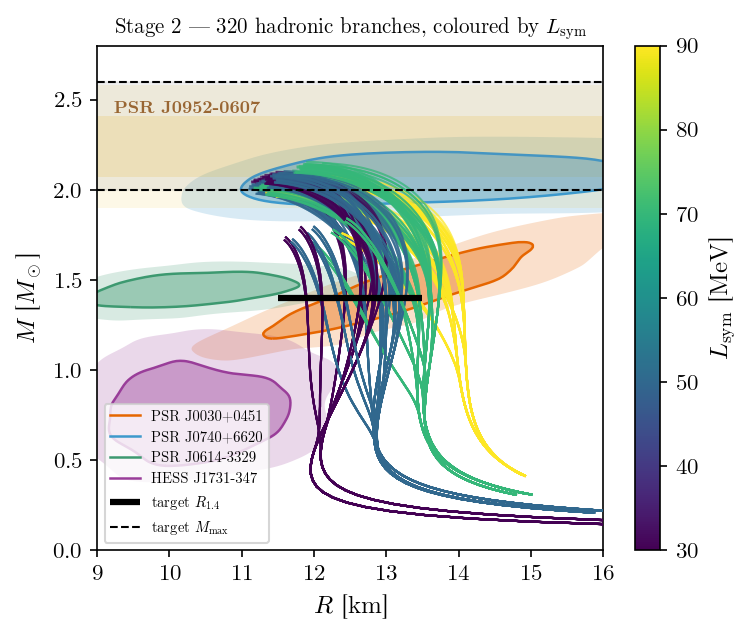

(95.9 s)


In [5]:
t0 = time.time()
print(f"drawing {len(had_ok)} hadronic sequences "
      f"(~{len(had_ok)*SEC_PER_HADRONIC:.0f} s)", flush=True)
_pars = Parallel(n_jobs=FUNNEL_JOBS)(
    delayed(build_parametrization)(s, FUNNEL_FLAGS) for s, _ in had_ok)
_curves = Parallel(n_jobs=FUNNEL_JOBS)(
    delayed(_hadronic_mr)(p, FUNNEL_FLAGS) for p, st, _ in _pars if st == "ok")
_Ls = [s["L_sym"] for (s, _), (p, st, _) in zip(had_ok, _pars) if st == "ok"]

# These funnel panels are on-screen diagnostics, not paper figures. Part III's
# paper_grid sets the publication rcParams globally, so re-assert the notebook
# style here in case a cell up here is re-run after Part III.
set_global_style()
fig, ax = plt.subplots(figsize=(5.2, 4.4))
_mr_axes(ax, f"Stage 2 — {len(_curves)} hadronic branches, coloured by "
             r"$L_{\rm sym}$")
# A one-value L_sym axis would give a degenerate colour scale, so widen it.
_lo, _hi = min(SCAN_L_SYM), max(SCAN_L_SYM)
_norm = plt.Normalize(_lo, _hi if _hi > _lo else _lo + 1.0)
for (R, M), _L in zip(_curves, _Ls):
    if R.size:
        ax.plot(R, M, lw=1.0, alpha=0.75, zorder=4,
                color=plt.cm.viridis(_norm(_L)))
fig.colorbar(plt.cm.ScalarMappable(norm=_norm, cmap="viridis"), ax=ax,
             label=r"$L_{\rm sym}$ [MeV]")
ax.legend(loc="lower left", fontsize=7)
fig.tight_layout()
plt.show()
print(f"({time.time()-t0:.1f} s)")

### Stage 3 — add quark matter: how many η work, and where does the centre sit?

In [6]:
good_nmp = [s for s, _ in had_ok]
had_row_of = {i: r for i, (_, r) in enumerate(had_ok)}
vmit_samples = grid_samples(B4=SCAN2_B4, a=SCAN2_A, m_s=SCAN2_MS)
ETA_GATE = min(FUNNEL_ETAS)
ETA_REST = [e for e in sorted(FUNNEL_ETAS) if e != ETA_GATE]

# ponytail: the eta = 0 (Gibbs) window is the widest one, so a combination with
# no window there has none at any higher eta and is not worth the other solves.
# The gate costs one eta and saves len(ETA_REST) on every reject. If a run ever
# needs to prove that, set ETA_GATE = 0.0 and ETA_REST = FUNNEL_ETAS to force
# every eta on every combination.
print(f"STAGE 3 — {len(good_nmp)} hadronic x {len(vmit_samples)} vMIT, gated "
      f"at eta={ETA_GATE}: {_budget(len(good_nmp)*len(vmit_samples), SEC_PER_HYBRID)}"
      f"\n   then eta in {ETA_REST} on whatever the gate passes — about half "
      f"of them historically, so budget roughly "
      f"{_budget(round(0.5*len(good_nmp)*len(vmit_samples)*len(ETA_REST)), SEC_PER_HYBRID)}"
      f" more", flush=True)
t0 = time.time()
gate_rows = scan_parameters(good_nmp, vmit_samples, FUNNEL_FLAGS, FUNNEL_GRID,
                            eta=ETA_GATE, T=0.0, tov=True, n_jobs=FUNNEL_JOBS)

pairs = [(i, s, v) for i, s in enumerate(good_nmp) for v in vmit_samples]
for _i, (_p, _r) in enumerate(zip(pairs, gate_rows)):
    _r["combo"] = float(_i)
    _r["nmp_index"] = float(_p[0])
survivors = [(i, p, r) for i, (p, r) in enumerate(zip(pairs, gate_rows))
             if r["window_exists"] == 1.0]

print(f"  gate: {len(survivors)}/{len(gate_rows)} have a window at "
      f"eta={ETA_GATE} ({time.time()-t0:.1f} s)")

t0 = time.time()
jobs = [(i, p, e) for i, p, _ in survivors for e in ETA_REST]
print(f"  {len(jobs)} remaining (combination, eta) solves")
rest_rows = list(Parallel(n_jobs=FUNNEL_JOBS, verbose=5)(
    delayed(scan_point)(p[1], p[2], FUNNEL_FLAGS, FUNNEL_GRID, eta=e, T=0.0,
                        tov=True, tov_parallel=False)
    for _, p, e in jobs))
for (_i, _p, _e), _r in zip(jobs, rest_rows):
    _r["combo"] = float(_i)
    _r["nmp_index"] = float(_p[0])

hyb_rows = gate_rows + rest_rows
by_combo = defaultdict(list)
for _r in hyb_rows:
    by_combo[int(_r["combo"])].append(_r)
for _rows in by_combo.values():
    _rows.sort(key=lambda r: r["eta"])
print(f"  {time.time()-t0:.1f} s for the remaining eta")

STAGE 3 — 320 hadronic x 30 vMIT, gated at eta=0.0: 9600 samples, ~69 min
   then eta in [0.3, 0.6, 1.0] on whatever the gate passes — about half of them historically, so budget roughly 14400 samples, ~103 min more


/Users/mircoguerrini/Desktop/Research/Python_codes/eos/eos/dd2/couplings.py:28: RuntimeWarning: overflow encountered in scalar power
  return 2.0 * a * (b - c) * (x + d) / (1.0 + c * (x + d) ** 2) ** 2
/Users/mircoguerrini/Desktop/Research/Python_codes/eos/eos/dd2/couplings.py:28: RuntimeWarning: overflow encountered in scalar power
  return 2.0 * a * (b - c) * (x + d) / (1.0 + c * (x + d) ** 2) ** 2
/Users/mircoguerrini/Desktop/Research/Python_codes/eos/eos/dd2/couplings.py:28: RuntimeWarning: overflow encountered in scalar power
  return 2.0 * a * (b - c) * (x + d) / (1.0 + c * (x + d) ** 2) ** 2
/Users/mircoguerrini/Desktop/Research/Python_codes/eos/eos/dd2/couplings.py:28: RuntimeWarning: overflow encountered in scalar power
  return 2.0 * a * (b - c) * (x + d) / (1.0 + c * (x + d) ** 2) ** 2
/Users/mircoguerrini/Desktop/Research/Python_codes/eos/eos/dd2/couplings.py:28: RuntimeWarning: overflow encountered in scalar power
  return 2.0 * a * (b - c) * (x + d) / (1.0 + c * (x + d) *

  gate: 2498/9600 have a window at eta=0.0 (5254.4 s)
  7494 remaining (combination, eta) solves


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  52 tasks      | elapsed:   43.4s
[Parallel(n_jobs=-1)]: Done 142 tasks      | elapsed:  2.2min
[Parallel(n_jobs=-1)]: Done 268 tasks      | elapsed:  4.2min
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:  6.5min
[Parallel(n_jobs=-1)]: Done 628 tasks      | elapsed:  8.9min
[Parallel(n_jobs=-1)]: Done 862 tasks      | elapsed: 11.9min
[Parallel(n_jobs=-1)]: Done 1132 tasks      | elapsed: 14.9min
[Parallel(n_jobs=-1)]: Done 1438 tasks      | elapsed: 18.0min
[Parallel(n_jobs=-1)]: Done 1780 tasks      | elapsed: 21.2min
[Parallel(n_jobs=-1)]: Done 2158 tasks      | elapsed: 24.9min
[Parallel(n_jobs=-1)]: Done 2572 tasks      | elapsed: 29.3min
[Parallel(n_jobs=-1)]: Done 3022 tasks      | elapsed: 33.2min
[Parallel(n_jobs=-1)]: Done 3508 tasks      | elapsed: 36.2min
[Parallel(n_jobs=-1)]: Done 4030 tasks      | elapsed: 39.2min
[Parallel(n_jobs=-1)]: Done 4588 tasks      | e

  3600.6 s for the remaining eta


[Parallel(n_jobs=-1)]: Done 7494 out of 7494 | elapsed: 60.0min finished


### The answer

In [7]:
# One summary per (NMP, sector, vMIT) combination. A combination with no window
# is still a star — the pure hadronic one — so it is judged on the stage-2
# hadronic numbers rather than being dropped.
summary = []
for _i, _rows in by_combo.items():
    _first = _rows[0]
    _had = had_row_of[int(_first["nmp_index"])]
    if _first["window_exists"] != 1.0:
        summary.append(dict(
            combo=_i, rows=_rows, n_eta=0, n_ok=0,
            phases={"none": len(_rows)},
            M_best=_had["M_max_had"], R_best=_had["R_1p4_had"],
            hadronic_in_band=(_in(_had["M_max_had"], M_MAX_RANGE)
                              and _in(_had["R_1p4_had"], R14_RANGE))))
        continue
    _ok = [r for r in _rows if _in(r["M_max"], M_MAX_RANGE)
           and _in(r["R_1p4"], R14_RANGE)]
    _M = [r["M_max"] for r in _rows if np.isfinite(r["M_max"])]
    summary.append(dict(
        combo=_i, rows=_rows, n_eta=len(_rows), n_ok=len(_ok),
        phases=dict(Counter(r["core_phase"] or "failed" for r in _rows)),
        M_best=(max(_M) if _M else np.nan),
        R_best=next((r["R_1p4"] for r in _ok), np.nan),
        hadronic_in_band=(_in(_had["M_max_had"], M_MAX_RANGE)
                          and _in(_had["R_1p4_had"], R14_RANGE))))

_all_eta = [s for s in summary if s["n_eta"] and s["n_ok"] == s["n_eta"]]
_some_eta = [s for s in summary if 0 < s["n_ok"] < s["n_eta"]]
_no_trans = [s for s in summary if s["n_eta"] == 0]
_phase_tally = Counter()
for s in summary:
    _phase_tally.update(s["phases"])

print(f"{len(summary)} combinations reached stage 3\n")
print(f"  {len(_all_eta):4d} in the target band at EVERY eta  "
      f"(M_max in {M_MAX_RANGE} M_sun, R_1.4 in {R14_RANGE} km)")
print(f"  {len(_some_eta):4d} in the target band at SOME eta")
print(f"  {len(_no_trans):4d} have NO transition at eta={ETA_GATE} — pure "
      f"hadronic stars, of which "
      f"{sum(1 for s in _no_trans if s['hadronic_in_band'])} are in band")
print(f"\n  where the centre of the M_max star sits, over all (combination, eta):")
for _p, _n in sorted(_phase_tally.items(), key=lambda kv: -kv[1]):
    _what = {"none": "no window — pure hadronic star",
             "H": "window above every stable star — no quarks in the star",
             "mix": "MIXED-PHASE core",
             "Q": "PURE QUARK core",
             "failed": "no maximum mass (eos_unphysical or TOV failure)"}
    print(f"    {_p:7s} {_n:5d}   {_what.get(_p, '')}")
print(f"\n  status breakdown: {dict(Counter(r['status'] for r in hyb_rows))}")

# The table. Sorted by how many eta land in the band, then by maximum mass.
# The columns are the axes swept by default; U_Lambda, U_Xi and x_rD are held
# at one value each and are in the saved tables if they are ever re-opened.
print(f"\n  K_sat  Q_sat  L_sym   m*/m  U_Sig    U_D  x_wD |    B4    a   m_s |"
      f"  eta | onset  offset |  M_max  R_1.4    n_Bc  core | status")
for _s in sorted(summary, key=lambda s: (-s["n_ok"], -(s["M_best"] if
                 np.isfinite(s["M_best"]) else -1)))[:FUNNEL_TOP]:
    _r0 = _s["rows"][0]
    _head = (f"  {_r0['K_sat']:6.1f} {_r0['Q_sat']:6.1f} {_r0['L_sym']:6.1f} "
             f"{_r0['m_eff_ratio']:6.4f} "
             f"{_r0['U_Sigma']:6.1f} {_r0['U_Delta']:6.1f} {_r0['x_wD']:5.2f} | "
             f"{_r0['B4']:5.1f} {_r0['a']:.2f} {_r0['m_s']:5.1f} |")
    print(f"{_head} {_s['n_ok']}/{max(_s['n_eta'], 1)} eta in band")
    if _s["n_eta"] == 0:
        _had = had_row_of[int(_r0["nmp_index"])]
        print(f"{' ' * len(_head)}  --- | no transition   | "
              f"{_had['M_max_had']:6.3f} {_had['R_1p4_had']:6.2f}     "
              f"---  none | {_r0['status']}")
        continue
    for _r in _s["rows"]:
        _flag = "*" if (_in(_r["M_max"], M_MAX_RANGE)
                        and _in(_r["R_1p4"], R14_RANGE)) else " "
        print(f"{' ' * len(_head)} {_r['eta']:4.2f} | {_r['n_onset']:5.3f} "
              f"{_r['n_offset']:6.3f} | {_r['M_max']:6.3f} {_r['R_1p4']:6.2f} "
              f"{_r['n_c_max']:7.3f}  {(_r['core_phase'] or '?'):4s}{_flag}| "
              f"{_r['status']}")

print("\n  Note: an onset below ~2 n_sat is formally allowed by these checks but")
print("  physically doubtful — uniform matter is not the ground state there.")

save_table(stage1_rows, OUT / "funnel_stage1_nmp.h5")
save_table(had_rows, OUT / "funnel_stage2_hadronic.h5",
           meta=dict(flags=FUNNEL_FLAGS))
save_table(hyb_rows, OUT / "funnel_stage3_hybrid.h5",
           meta=dict(flags=FUNNEL_FLAGS))
export_csv(had_rows, OUT / "funnel_stage2_hadronic.csv")
export_csv(hyb_rows, OUT / "funnel_stage3_hybrid.csv")

# The recipe for the best combination, ready to paste into I.3 and re-run at
# the full NB resolution — the funnel deliberately runs on a coarse grid.
_best = max(summary, key=lambda s: (s["n_ok"], s["M_best"]
                                    if np.isfinite(s["M_best"]) else -1))
if _best["n_ok"]:
    _b = _best["rows"][0]
    print(f"\n{'=' * 78}\nBest combination — paste into I.3 and re-run Part II "
          f"on the full NB grid:\n")
    print(f"NMP = dict(n_sat={_b['n_sat']:.6f}, E_sat={_b['E_sat']:.2f}, "
          f"m_eff_ratio={_b['m_eff_ratio']:.4f},\n"
          f"           K_sat={_b['K_sat']:.1f}, Q_sat={_b['Q_sat']:.2f}, "
          f"E_sym={_b['E_sym']:.2f}, L_sym={_b['L_sym']:.2f})")
    print(f"PAR = Parametrization.from_nmp(NMP)")
    print(f"PAR = Parametrization.from_hyperon_potentials("
          f"U_Lambda={_b['U_Lambda']:.1f}, U_Sigma={_b['U_Sigma']:.1f}, "
          f"U_Xi={_b['U_Xi']:.1f}, base=PAR)")
    print(f"PAR = Parametrization.from_delta_potential("
          f"U_Delta={_b['U_Delta']:.1f}, x_wD={_b['x_wD']:.2f}, "
          f"x_rD={_b['x_rD']:.2f}, base=PAR)")
    print(f"VMIT = get_vmit_custom(B4={_b['B4']:.1f}, a={_b['a']:.2f}, "
          f"m_s={_b['m_s']:.1f})")
else:
    print(f"\nNothing landed in the target band. a and B^1/4 both raise the "
          f"onset, so move\nthem in OPPOSITE directions: lower SCAN2_B4 if a "
          f"is at 0.20, raise it towards\n200 if a is at 0.10. Going above "
          f"a = 0.20 does not help; the ordered window\nis gone there for any "
          f"B^1/4.")

9600 combinations reached stage 3

   445 in the target band at EVERY eta  (M_max in (2.0, 2.6) M_sun, R_1.4 in (11.5, 13.5) km)
   360 in the target band at SOME eta
  7102 have NO transition at eta=0.0 — pure hadronic stars, of which 2888 are in band

  where the centre of the M_max star sits, over all (combination, eta):
    none     7102   no window — pure hadronic star
    Q        6120   PURE QUARK core
    failed   1602   no maximum mass (eos_unphysical or TOV failure)
    mix      1353   MIXED-PHASE core
    H         917   window above every stable star — no quarks in the star

  status breakdown: {'no_transition': 7648, 'eos_unphysical': 421, 'crossings_out_of_order': 412, 'ok': 8390, 'offset_unbracketed': 223}

  K_sat  Q_sat  L_sym   m*/m  U_Sig    U_D  x_wD |    B4    a   m_s |  eta | onset  offset |  M_max  R_1.4    n_Bc  core | status
   250.0  350.0   70.0 0.5625   30.0 -100.0  1.20 | 170.0 0.20 150.0 | 4/4 eta in band
                                                   

#### The finalists, as mass-radius curves

The same picture as the stage-2 panel, one η per colour, for the best `FUNNEL_TOP`
combinations. Compare it against stage 2: the hadronic family was a broad fan set by
`L_sym`, and adding the transition pulls the top of each curve — a first-order
transition softens the equation of state above the onset, so M_max falls and the peak
moves left, while R(1.4) is untouched whenever the onset sits above the central
density of a 1.4 M_sun star.

A curve whose peak lands inside the dashed band **and** whose M = 1.4 crossing lands
on the thick bar is a combination that passes at that η. Solid means the centre of
the maximum-mass star is mixed or quark; dashed means the window exists but no stable
star reaches it.

drawing 80 hybrid sequences (~34 s)


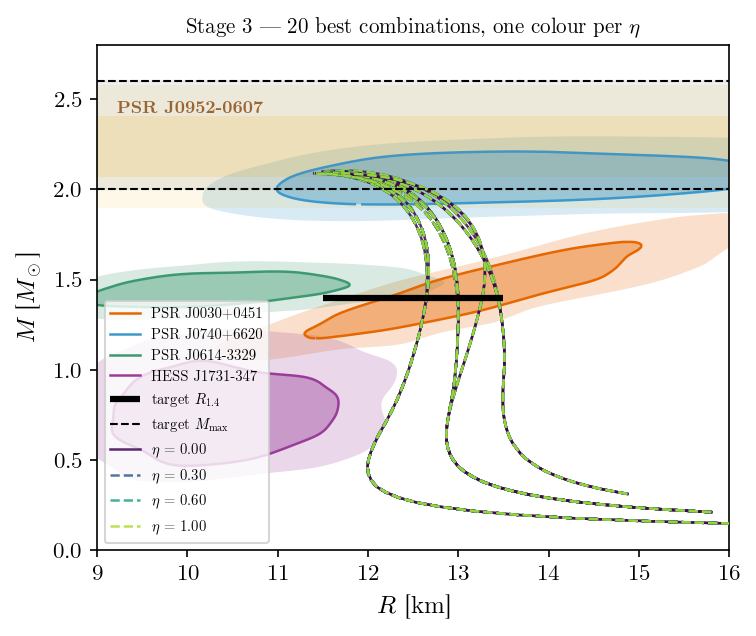

(27.0 s)


In [8]:
_show = [s for s in sorted(summary, key=lambda s: (-s["n_ok"], -(s["M_best"]
         if np.isfinite(s["M_best"]) else -1))) if s["n_eta"]][:FUNNEL_TOP]
_jobs = [(s["combo"], r) for s in _show for r in s["rows"]
         if np.isfinite(r["M_max"])]
print(f"drawing {len(_jobs)} hybrid sequences "
      f"(~{len(_jobs)*SEC_PER_HYBRID:.0f} s)", flush=True)
t0 = time.time()


def _hybrid_mr(row):
    """(R, M) of one stitched hybrid sequence, stable branch only.

    Rebuilt from the row's own parameters, so the curve belongs to the numbers
    printed beside it. `mass_radius_mixed` returns the raw TOV array, which the
    scan row does not carry.
    """
    try:
        par, st, _ = build_parametrization(
            {k: row[k] for k in PAR_KEYS if k in row}, FUNNEL_FLAGS)
        if st != "ok":
            return np.array([]), np.array([])
        vm = get_vmit_custom(B4=row["B4"], a=row["a"], m_s=row["m_s"])
        res = mass_radius_mixed(par, FUNNEL_FLAGS, FUNNEL_GRID, row["eta"],
                                beta_eq_neutrinoless(), vmit_params=vm, T=0.0,
                                n_ec=120, compute_tidal=False,
                                tov_parallel=False)["results"]
        i, _, _ = find_mmax_precise(res)
        return res[:i + 1, 3], res[:i + 1, 4]
    except Exception:
        return np.array([]), np.array([])


_hyb_curves = Parallel(n_jobs=FUNNEL_JOBS)(
    delayed(_hybrid_mr)(r) for _, r in _jobs)

set_global_style()          # diagnostic panel, not a paper figure (see stage 2)
fig, ax = plt.subplots(figsize=(5.2, 4.4))
_mr_axes(ax, f"Stage 3 — {len(_show)} best combinations, one colour per "
             r"$\eta$")
_seen = set()
for ((_c, _r), (R, M)) in zip(_jobs, _hyb_curves):
    if not R.size:
        continue
    _lab = None if _r["eta"] in _seen else rf"$\eta$ = {_r['eta']:.2f}"
    _seen.add(_r["eta"])
    ax.plot(R, M, lw=1.2, alpha=0.85, zorder=4,
            color=FUNNEL_ETA_COLOR.get(_r["eta"], "0.3"), label=_lab,
            ls=("-" if _r["core_phase"] in ("mix", "Q") else "--"))
ax.legend(loc="lower left", fontsize=7)
fig.tight_layout()
plt.show()
print(f"({time.time()-t0:.1f} s)")

## I.3 Parameters and grids

Everything tunable lives in this cell. Edit, then run the rest.

In [9]:
# ---- hadronic parametrization -------------------------------------------
#   # 1. nucleons: invert the nuclear-matter parameters at saturation
#   NMP = dict(n_sat=0.149065, E_sat=-16.02, m_eff_ratio=0.5625,
#              K_sat=242.7, Q_sat=169.15, E_sym=31.67, L_sym=55.03)
#   PAR = Parametrization.from_nmp(NMP)          # add return_status=True to
#                                                # inspect the inversion residuals
#
#   # 2. hyperons: SU(6) vectors, scalars inverted from the potentials in SNM.
#   #    Re-solves SNM on `base`, so it adapts to the NMP nucleon sector.
#   PAR = Parametrization.from_hyperon_potentials(
#       U_Lambda=-30.0, U_Sigma=30.0, U_Xi=-18.0, base=PAR)
#
#   # 3. Delta: no SU(6) rule exists, so set x_iD = Gamma_iD/Gamma_iN by hand.
#   PAR = replace(PAR, x_Delta_sigma=1.15, x_Delta_omega=1.0, x_Delta_rho=1.0)

NMP = dict(n_sat=0.149077, E_sat=-16.02, m_eff_ratio=0.5625,
           K_sat=290.0, Q_sat=300.00, E_sym=31.67, L_sym=50.00)
# The sector potentials live in their own dicts so I.4 can rebuild exactly this
# parametrization from them rather than restating the numbers.
HYPERON_U = dict(U_Lambda=-30.0, U_Sigma=30.0, U_Xi=-10.0)
DELTA_U = dict(U_Delta=-50.0, x_wD=1.20, x_rD=1.00)

# `from_nmp` does NOT raise when the inversion misses — it returns the closest
# couplings it reached — so ask for the status and say so. The isoscalar sector
# is a square system closed by f_sigma''(1) = f_omega''(1), which ties K_sat and
# Q_sat together; a pair that is inconsistent with that constraint is silently
# realised as the nearest pair that is. I.4 measures how much room there is.
PAR, _status = Parametrization.from_nmp(NMP, return_status=True)
PAR = Parametrization.from_hyperon_potentials(base=PAR, **HYPERON_U)
PAR = Parametrization.from_delta_potential(base=PAR, **DELTA_U)
VMIT = get_vmit_custom(B4=170.0, a=0.20, m_s=150.0)

NMP_REALISED = compute_nmp(PAR)
if not _status.ok:
    print("WARNING: the NMP inversion did not converge — the model below is "
          "NOT the one written above.")
    print(f"  {_status.message}")
print(f"{'NMP':<13}{'asked':>10}{'realised':>10}{'diff':>9}")
for _k, _v in NMP.items():
    _flag = "  <--" if abs(NMP_REALISED[_k] - _v) > 1e-3 * max(abs(_v), 1.0) else ""
    print(f"  {_k:<11}{_v:>10.4f}{NMP_REALISED[_k]:>10.4f}"
          f"{NMP_REALISED[_k] - _v:>9.4f}{_flag}")
print()


# ---- which degrees of freedom exist --------------------------------------
# Every species is an explicit flag; nothing is switched on implicitly, and a
# flag that is not wired raises rather than being quietly ignored.
FLAGS = SpeciesFlags(
    hyperons=True,      # Lambda, Sigma, Xi        (needs hyperon couplings)
    deltas=True,        # Delta quartet
    muons=True,         # electrons are always present; muons optional
    phi_field=True,     # hidden-strange vector, required with hyperons
    photons=True,       # matters only at T > 0
    include_pseudoscalars=True,     # thermal pi, K, eta, eta'
    include_thermal_vectors=True,   # thermal rho, omega, K*, phi
)




# ---- equilibrium modes ----------------------------------------------------
# 'beta_eq_neutrinoless'      independent variables (nB, T)
# 'beta_eq_neutrino_trapped'  independent variables (nB, Y_L, T)
# 'fixed_YC'                  independent variables (nB, Y_C, T)
# 'fixed_YC_YS'               independent variables (nB, Y_C, Y_S, T)
#
# RUNS is the list of tables Part II builds: one entry per mode, carrying the
# fraction AXES that mode sweeps (empty for beta equilibrium, which has none).
# Add or remove an entry to change what gets tabulated; every plot in Part III
# selects out of whatever is on disk.
#
# Naming trap worth stating once: eos.mixed's `fixed_YC(Y_C, leptons=True)` —
# what `leptons=True` in MixedTableSpec selects — is the mode eos.dd2 spells
# `fixed_YC_neutral`, i.e. hadrons at fixed non-leptonic charge fraction PLUS
# electrons (and muons) making the total electrically neutral. eos.dd2's bare
# `fixed_YC` is the LEPTONLESS CompOSE (nB, T, Y_q) slice, which is a different
# physical system. II.1 builds the pure wings with charge_mode="fixed",
# yc_leptons=True so they match the mixed tables.
Y_C_LIST = [0.1, 0.3, 0.4, 0.5]      # the Y_C axis, for the fixed-Y_C modes
FIXED = {}                      # scalar values for fractions not swept as axes

RUNS = [
    ("beta_eq_neutrinoless", {}),
    ("fixed_YC", {"Y_C": Y_C_LIST}),
]
#: The mode II.3 (TOV) and II.4 (parameter scan) use. Both are cold,
#: neutrinoless, beta-equilibrated by construction — see II.3.
MODE = RUNS[0][0]

# ---- grids ----------------------------------------------------------------
N_SAT = PAR.n_sat                                     # fm^-3
NB = np.linspace(0.1 * N_SAT, 12.0 * N_SAT, 300)      # baryon density [fm^-3]
T_LIST = np.concatenate([[0, 0.1], np.arange(2.5, 101., 2.5)])  # MeV
ETA_LIST = [0.0, 0.1, 0.3, 0.6, 1.0]

# ---- what to run ----------------------------------------------------------
TOV_ETAS = ETA_LIST     # TOV is beta-equilibrium, T = 0 only

# How many (mode, eta) table builds run at once in II.2. eta is the natural
# axis to split on: it changes the shape of the unknown vector, so the eta
# loop was already the outer one and no warm start crosses it. The T chain
# inside each job stays serial, which is where the warm starting lives.
BUILD_JOBS = len(ETA_LIST)

# ---- figures (Part III) ---------------------------------------------------
# paper_grid builds at the true page width so 10 pt text lands as 10 pt on
# paper. FIG_WIDTH overrides that when a panel is too dense to read at 7 in —
# set it back to None for a figure going into the paper at 1:1.
FIG_WIDTH = 9.0                 # inches, or None to use the true PRD width
Y_FLOOR = 1e-4                  # smallest particle fraction drawn

# ---- parameter scan (II.4) ------------------------------------------------
# The map of where a hybrid star exists at all. Kept coarse by default; each
# (B4, a) pair costs roughly a second with TOV on.
SCAN_B4 = [150.0, 160.0, 170.0, 180.0, 190.0]     # MeV
SCAN_A = [0.05, 0.10, 0.15, 0.20]                 # fm^2 (>= 0.25 has no window)
SCAN_GRID = np.linspace(0.05, 1.6, 120)           # coarser than NB: a probe
SCAN_TOV = True                                   # also record M_max, R_1.4

# ---- rotation (III.7) -----------------------------------------------------
# Uniformly rotating models, computed by RNS through eos.tov.rotating. One
# axis-ratio scan per central density answers every J and every frequency at
# once, so the cost is ROT_N_SCAN solver runs per (eta, n_B_c) and is set by
# ROT_N_SCAN x len(ROT_NB_C), not by how many isolines you ask for.
ROT_NB_C = np.linspace(0.4, 1.6, 13)      # central baryon density [fm^-3]
ROT_J = [0.5, 1.0, 1.5, 2.0]              # angular momentum, cJ/(G M_sun^2)
ROT_FREQ = [300.0, 600.0, 900.0, 1200.0]  # spin frequency [Hz]
ROT_ETA_SHOW = 0.0                        # eta for the two isoline panels
ROT_N_SCAN = 14                           # axis ratios per central density

# The hyperon couplings live in DD2Y and nowhere else — DD2 has no entry for
# Lambda — so `hyperons=True` on `from_dd2_defaults()` fails deep in the
# coupling lookup with a bare KeyError. Catch the mismatch here instead.
if FLAGS.hyperons and not PAR.hyperon_coupling_map:
    raise ValueError("FLAGS.hyperons=True needs a parametrization that carries "
                     "hyperon couplings — from_dd2y_defaults() or "
                     "from_hyperon_potentials(); the DD2 defaults carry none")

print(f"n_sat = {N_SAT:.6f} fm^-3")
print(f"n_B  : {NB[0]:.4f} .. {NB[-1]:.4f} fm^-3  ({len(NB)} points, "
      f"{NB[0]/N_SAT:.1f}-{NB[-1]/N_SAT:.1f} n_sat)")
print(f"T    : {T_LIST}")
print(f"eta  : {ETA_LIST}")
print(f"runs : " + ";  ".join(
    f"{m}" + ("" if not ax else " (" + ", ".join(
        f"{k}={v}" for k, v in ax.items()) + ")") for m, ax in RUNS))
print(f"species: "
      f"{'hyperons ' if FLAGS.hyperons else ''}{'deltas ' if FLAGS.deltas else ''}"
      f"{'muons ' if FLAGS.muons else ''}nucleons+electrons")
print(f"vMIT : B^1/4={VMIT.B4} MeV, a={VMIT.a} fm^2, m_s={VMIT.m_s} MeV")

# How much Part II.2 is about to cost, before it starts.
_n_jobs = sum(max(1, int(np.prod([len(v) for v in ax.values()])) if ax else 1)
              for _, ax in RUNS) * len(ETA_LIST) * len(T_LIST)
print(f"\nII.2 will locate {_n_jobs} windows "
      f"({len(RUNS)} runs x {len(ETA_LIST)} eta x {len(T_LIST)} T x fractions),"
      f" {BUILD_JOBS} at a time")
print(f"\nNote: below ~0.5 n_sat and at low T, uniform matter sits inside the")
print(f"liquid-gas spinodal and has no stable solution; those points are skipped.")

NMP               asked  realised     diff
  n_sat          0.1491    0.1491   0.0000
  E_sat        -16.0200  -16.0200  -0.0000
  m_eff_ratio    0.5625    0.5625  -0.0000
  K_sat        290.0000  290.0015   0.0015
  Q_sat        300.0000  301.3419   1.3419  <--
  E_sym         31.6700   31.6700   0.0000
  L_sym         50.0000   50.0000   0.0000

n_sat = 0.149077 fm^-3
n_B  : 0.0149 .. 1.7889 fm^-3  (300 points, 0.1-12.0 n_sat)
T    : [  0.    0.1   2.5   5.    7.5  10.   12.5  15.   17.5  20.   22.5  25.
  27.5  30.   32.5  35.   37.5  40.   42.5  45.   47.5  50.   52.5  55.
  57.5  60.   62.5  65.   67.5  70.   72.5  75.   77.5  80.   82.5  85.
  87.5  90.   92.5  95.   97.5 100. ]
eta  : [0.0, 0.1, 0.3, 0.6, 1.0]
runs : beta_eq_neutrinoless;  fixed_YC (Y_C=[0.1, 0.3, 0.4, 0.5])
species: hyperons deltas muons nucleons+electrons
vMIT : B^1/4=170.0 MeV, a=0.2 fm^2, m_s=150.0 MeV

II.2 will locate 1050 windows (2 runs x 5 eta x 42 T x fractions), 5 at a time

Note: below ~0.5 n_sat and

## I.4 What else is being held fixed, and does it matter?

A scan reports on the axes it sweeps and says nothing about the axes it does not. I.2
moves `K_sat`, `Q_sat`, `L_sym`, `m*/m` and the sector potentials; it holds `n_sat`,
`E_sat`, `E_sym`, the sigma mass `m_sigma` and the Δ isovector ratio `x_rD` at one value
each. Holding a parameter fixed is a physics claim — *this one does not matter for the
question being asked* — and it is worth checking rather than assuming.

So: move each held-fixed parameter one at a time to the ends of its literature range,
leave everything else at the I.3 choice, and record M_max, R(1.4) and the transition
onset. Sorted by effect, this ranks which knobs the funnel *should* be sweeping.

**`m_eff_ratio` is the one to watch, and it comes with a catch.** In a density-dependent
RMF the effective mass at saturation fixes the scalar coupling strength, so it controls
how fast the scalar field saturates — hence the stiffness above ~2 n_sat, which is what
sets M_max — *and* the density at which each hyperon and Δ threshold opens, because
those thresholds are crossings of the baryon effective masses. Two routes to the maximum
mass, neither acting through R(1.4).

**The catch: `Q_sat` cannot be held while an isoscalar parameter moves.** The isoscalar
sector has six free couplings matched to six conditions — P(n_sat)=0, E_sat, m\*/m,
K_sat, Q_sat and the closing cross-constraint f_σ''(1) = f_ω''(1) — so it is a square
system, and `m*/m`, `n_sat` and `E_sat` are all tied to `Q_sat` through it. Moving one
of them at fixed `Q_sat` asks for a DD-RMF realisation that does not exist, and the
inversion correctly reports `inversion_failed`. Every row below therefore **refits
`Q_sat`**, taking the value nearest the I.3 choice that inverts, and prints which one it
used. The row then measures "move this parameter and let Q_sat follow", which is the
only comparison the functional form permits.

That constraint is itself a result: on this ladder `m*/m` inverts over roughly 0.50–0.60
and **nowhere above ~0.61 for any `Q_sat` in [100, 600] MeV**. It is the most tightly
boxed-in of the held-fixed parameters, which is worth knowing before reading a small
number in its ΔM_max column as "this does not matter".

`m_sigma` is not a nuclear-matter parameter and cannot go through
`build_parametrization`, so it takes its own path via `Parametrization.from_nmp(nmp,
m_sigma=...)`. Only the sigma mass is genuinely free — the omega and rho masses are
measured.

In [10]:
# parameter -> (low, high). Ranges are the span the literature uses, not error
# bars: the question is the size of the effect across plausible values.
HELD_FIXED = {
    "m_eff_ratio": (0.52, 0.60),    # m*/m at saturation; see the markdown
    "n_sat":       (0.145, 0.155),  # fm^-3
    "E_sat":       (-16.5, -15.5),  # MeV
    "E_sym":       (29.0, 34.0),    # MeV
    "x_rD":        (0.8, 1.2),      # Delta isovector coupling ratio
}
SENS_M_SIGMA = (520.0, 570.0)       # MeV, its own call path (see the markdown)
SENS_Q_LADDER = np.arange(100.0, 601.0, 25.0)   # MeV, the refit values tried
SENS_GRID = np.linspace(0.05, 1.6, 120)         # coarser than NB: a probe

#: The I.3 parametrization as a flat sample dict, which is what the inverter
#: takes. Built from the same NMP / HYPERON_U / DELTA_U, so it cannot drift.
SENS_BASE = dict(NMP, **HYPERON_U, **DELTA_U)


def _sens_par(sample, m_sigma=None):
    """(Parametrization, the Q_sat it needed) for one variant, or (None, nan).

    Q_sat is refit rather than held — see the markdown above. The ladder is
    walked outwards from the I.3 value, so a variant that does invert at the
    original Q_sat keeps it and the row stays a clean one-at-a-time change.
    """
    for q in sorted(SENS_Q_LADDER, key=lambda x: abs(x - SENS_BASE["Q_sat"])):
        s = dict(sample, Q_sat=float(q))
        if m_sigma is None:
            par, stage, _ = build_parametrization(s, FLAGS)
            if stage == "ok":
                return par, float(q)
            continue
        # m_sigma is not a nuclear-matter parameter, so build_parametrization
        # has no slot for it. Go through from_nmp and add the two sectors by
        # hand, which is what build_parametrization does internally anyway.
        try:
            par = Parametrization.from_nmp({k: s[k] for k in NMP_KEYS},
                                           m_sigma=m_sigma)
            par = Parametrization.from_hyperon_potentials(
                base=par, **{k: s[k] for k in HYPERON_U})
            return (Parametrization.from_delta_potential(
                base=par, **{k: s[k] for k in DELTA_U}), float(q))
        except Exception:
            continue
    return None, np.nan


def _sens_point(sample, m_sigma=None):
    """(M_max, R_1.4, n_onset, Q_sat used) for one parameter choice.

    The full hybrid star at eta = 0, which is the widest window and so the one
    most likely to exist. Anything that does not converge comes back nan rather
    than raising, so one unreachable corner does not stop the table.
    """
    par, q_used = _sens_par(sample, m_sigma)
    if par is None:
        return np.nan, np.nan, np.nan, np.nan
    try:
        core = build_mixed_eos_table(par, FLAGS, SENS_GRID, 0.0,
                                     beta_eq_neutrinoless(), vmit_params=VMIT,
                                     T=0.0)
        res = mass_radius_mixed(par, FLAGS, SENS_GRID, 0.0,
                                beta_eq_neutrinoless(), vmit_params=VMIT,
                                T=0.0, table=core, n_ec=60,
                                compute_tidal=False, tov_parallel=False)
        return res["M_max"], res["R_1p4"], core.n_onset, q_used
    except Exception:
        return np.nan, np.nan, np.nan, q_used


# One variant per (parameter, end of its range), plus the baseline.
sens_variants = []                              # (name, value, sample, m_sigma)
for _key, (_lo, _hi) in HELD_FIXED.items():
    for _val in (_lo, _hi):
        sens_variants.append((_key, _val, dict(SENS_BASE, **{_key: _val}), None))
for _ms in SENS_M_SIGMA:
    sens_variants.append(("m_sigma", _ms, dict(SENS_BASE), _ms))

t0 = time.time()
print(f"I.4 — {len(sens_variants) + 1} parametrizations, each one TOV sweep "
      f"on a {len(SENS_GRID)}-point grid", flush=True)
sens_out = Parallel(n_jobs=-1)(
    delayed(_sens_point)(s, ms) for _, _, s, ms in sens_variants)
sens_base = _sens_point(SENS_BASE)
sens_by = {(name, val): res for (name, val, _, _), res
           in zip(sens_variants, sens_out)}

print(f"\n  baseline (I.3): M_max={sens_base[0]:.3f} Msun  "
      f"R_1.4={sens_base[1]:.2f} km  n_onset={sens_base[2]:.3f} fm^-3  "
      f"at Q_sat={sens_base[3]:.0f} MeV\n")
print(f"  {'held fixed':<13} {'low':>8} {'high':>8} | {'dM_max':>8} "
      f"{'dR_1.4':>8} {'dn_onset':>9} | {'Q_sat refit':>13}")

sens_rows = []
for _key, (_lo, _hi) in list(HELD_FIXED.items()) + [("m_sigma", SENS_M_SIGMA)]:
    _a, _b = sens_by[(_key, _lo)], sens_by[(_key, _hi)]
    # The full swing across the range: "does it matter" is a question about the
    # whole plausible interval, not a derivative at one point.
    _swing = [abs(x - y) for x, y in zip(_a[:3], _b[:3])]
    sens_rows.append((_key, _lo, _hi, _swing, (_a[3], _b[3])))

# Ranked by the effect on M_max, the number the funnel is actually filtering on.
for _key, _lo, _hi, _s, _q in sorted(
        sens_rows, key=lambda r: -(r[3][0] if np.isfinite(r[3][0]) else -1)):
    print(f"  {_key:<13} {_lo:8.4g} {_hi:8.4g} | {_s[0]:8.3f} {_s[1]:8.2f} "
          f"{_s[2]:9.3f} | {_q[0]:6.0f} {_q[1]:6.0f}")

print("\n  Read every column as the FULL SWING across that range, which makes it")
print("  directly comparable with the swept axes: over 30-90 MeV L_sym moves")
print("  R(1.4) by 1.21 km and M_max by 0.028 Msun. Anything here with a")
print("  comparable dM_max belongs on a scan axis rather than in this table.")
print("  A nan is a range end with no DD-RMF realisation at any Q_sat on the")
print("  ladder — a statement about the functional form, not a flat response.")
print(f"({time.time()-t0:.1f} s)")

I.4 — 13 parametrizations, each one TOV sweep on a 120-point grid

  baseline (I.3): M_max=2.114 Msun  R_1.4=13.33 km  n_onset=0.334 fm^-3  at Q_sat=300 MeV

  held fixed         low     high |   dM_max   dR_1.4  dn_onset |   Q_sat refit
  m_eff_ratio       0.52      0.6 |    0.048     0.07     0.012 |    450    350
  n_sat            0.145    0.155 |    0.041     0.38     0.030 |    300    325
  E_sym               29       34 |    0.016     0.12     0.010 |    300    300
  E_sat            -16.5    -15.5 |    0.013     0.02     0.000 |    300    300
  m_sigma            520      570 |    0.000     0.00     0.000 |    300    300
  x_rD               0.8      1.2 |    0.000     0.00     0.000 |    300    300

  Read every column as the FULL SWING across that range, which makes it
  directly comparable with the swept axes: over 30-90 MeV L_sym moves
  R(1.4) by 1.21 km and M_max by 0.028 Msun. Anything here with a
  comparable dM_max belongs on a scan axis rather than in this table.
  A

# Part II — tables

The build proceeds in the order the physics suggests:

1. **the two pure phases** on the whole density grid — cheap, and they are both the
   seeds for the mixed solve and the wings of the final table;
2. **the transition boundaries**, found by reading χ and bracketing its 0 and 1
   crossings;
3. **the mixed phase**, solved only between those boundaries, warm-started from one
   density to the next.

## II.1 Pure phases

Useful on their own, and a quick check that both engines cover the grid before the
expensive part starts.

Both wings are built for **every** entry of `RUNS`, not just for β-equilibrium. They
have to be: outside the transition window the equation of state *is* the pure phase, so
a fixed-Y_C panel whose wings were built in β-equilibrium would show a discontinuity at
the onset that is an artefact of mixing two different physical systems. `full_eos` in
Part III joins the wings to the window that shares its (mode, fractions, T).

In [11]:
def _columns(rows):
    """A list of flat dicts to a {name: array} table.

    String label columns (`phase`) are dropped — everything below slices and
    plots numerically, so carrying them would only force a dtype check at
    every use.
    """
    return {k: np.array([r[k] for r in rows], dtype=float) for k in rows[0]
            if not isinstance(rows[0][k], str)}


def _quark_row(q):
    """One pure-quark point, keyed like `hadronic_row` / `composition_row`, so
    the pure wings and the mixed window concatenate in Part III without
    renaming anything. chi = 1: no hadronic matter left.

    Y_C and Y_S are DERIVED from the quark densities rather than read off the
    result. `VMITEOSResult.Y_C` / `.Y_S` are the *targets* of the fixed-fraction
    solvers and are left at their 0.0 default by `solve_vmit_beta_eq`, so
    reading them here would silently report a strangeness fraction of zero for
    matter that is nearly one third strange. `quark_charges` is the repository's
    own definition, so this also picks up the S = +1 per s-quark convention
    instead of restating it.
    """
    from eos.mixed import quark_charges
    n_B, n_C, n_S = quark_charges(q.n_u, q.n_d, q.n_s)
    return dict(n_B=q.n_B, T=q.T, chi=1.0, P=q.P_total, eps=q.e_total,
                s=q.s_total, S_per_B=(q.s_total / q.n_B if q.n_B else 0.0),
                mu_B=q.mu_B, Y_C=n_C / n_B, Y_S=n_S / n_B,
                Y_u=q.Y_u, Y_d=q.Y_d, Y_s=q.Y_s, Y_e=q.Y_e)


def _add_phase_split(row, phase):
    """Give a pure-phase row the per-phase charge columns a mixed row carries.

    In a pure phase the partition is trivial — one phase holds everything — but
    it has to be written down, or the H/Q/total curves of III.7 exist only
    between the two boundaries and the figure says nothing about the wings.
    The leptons are assigned to the phase that is present, which is what makes
    the local-lepton curves continuous into the Maxwell window; at eta = 0 they
    step instead, because there the leptons genuinely are a global background
    belonging to neither phase. That step is physics, not a plotting artefact.
    """
    other = "Q" if phase == "H" else "H"
    row[f"Y_B_{phase}"] = 1.0
    row[f"Y_C_{phase}"] = row["Y_C"]
    row[f"Y_S_{phase}"] = row["Y_S"]
    row[f"Y_L_{phase}"] = row.get("Y_e", 0.0) + row.get("Y_mu-", 0.0)
    for q in ("B", "C", "S", "L"):
        row[f"Y_{q}_{other}"] = 0.0
    row["Y_L_G"] = 0.0
    return row


def frac_combos(axes):
    """The fraction axes of one RUNS entry, expanded to a list of dicts.

    `{}` (beta equilibrium, no fractions) gives `[{}]` — one combination, not
    none — so every mode is looped the same way.
    """
    import itertools
    keys = sorted(axes)
    return [dict(zip(keys, vals))
            for vals in itertools.product(*(axes[k] for k in keys))] or [{}]


def frac_key(fracs):
    """A dict of fractions as a hashable, order-independent key."""
    return tuple(sorted((k, round(float(v), 6)) for k, v in fracs.items()))


def pure_key(mode, fracs, T):
    return (mode, frac_key(fracs), round(float(T), 6))


t0 = time.time()
pure_hadronic, pure_quark, pure_counts = {}, {}, []
for mode, axes in RUNS:
    for fracs in frac_combos(axes):
        label = mode + ("" if not fracs else
                        " " + " ".join(f"{k}={v}" for k, v in fracs.items()))
        for T in T_LIST:
            key = pure_key(mode, fracs, T)

            # ---- hadronic wing -------------------------------------------
            if mode == "beta_eq_neutrinoless":
                pts = sweep_beta_eq_octet(PAR, NB, FLAGS, T=T,
                                          stop_at_boundary=True)
            elif mode == "fixed_YC":
                # charge_mode="fixed" + yc_leptons=True is eos.dd2's
                # `fixed_YC_neutral`, the mode that matches the mixed tables
                # (see the naming note in I.3).
                pts = sweep_octet(PAR, NB, FLAGS, T=T, charge_mode="fixed",
                                  Y_C=fracs["Y_C"], yc_leptons=True,
                                  stop_at_boundary=True)
            else:
                raise NotImplementedError(
                    f"II.1 has no pure-hadronic wing for mode {mode!r}; add one "
                    f"beside the fixed_YC branch rather than falling back to "
                    f"beta equilibrium, which would be a different system")
            if pts:
                # `hadronic_row` keys a pure-hadronic point exactly the way
                # `composition_row` keys a mixed one. It also sums Y_C and Y_S
                # over every active baryon rather than reading them off the
                # proton, which matters the moment hyperons are switched on.
                pure_hadronic[key] = _columns(
                    [_add_phase_split(hadronic_row(p, FLAGS), "H")
                     for p in pts])

            # ---- quark wing ----------------------------------------------
            rows = []
            for n in NB:
                try:
                    if mode == "beta_eq_neutrinoless":
                        q = solve_vmit_beta_eq(float(n), T, params=VMIT)
                    else:
                        q = solve_vmit_fixed_yc(float(n), fracs["Y_C"], T,
                                                params=VMIT,
                                                include_electrons=True)
                    rows.append(_add_phase_split(_quark_row(q), "Q"))
                except Exception:
                    continue
            if rows:
                pure_quark[key] = _columns(rows)

            pure_counts.append(dict(mode=mode, T=float(T),
                                    n_had=len(pts), n_quark=len(rows),
                                    n_grid=len(NB),
                                    **{k: float(v) for k, v in fracs.items()}))
        print(f"  {label:<28} : hadronic "
              f"{min(r['n_had'] for r in pure_counts[-len(T_LIST):]):3d}-"
              f"{max(r['n_had'] for r in pure_counts[-len(T_LIST):]):3d}"
              f" / quark "
              f"{min(r['n_quark'] for r in pure_counts[-len(T_LIST):]):3d}-"
              f"{max(r['n_quark'] for r in pure_counts[-len(T_LIST):]):3d}"
              f"  of {len(NB)} points, over {len(T_LIST)} T", flush=True)

print(f"\npure phases: {time.time()-t0:.1f} s, "
      f"{len(pure_hadronic)} hadronic + {len(pure_quark)} quark slices")
print("Points below the full grid count are expected at low T: uniform matter")
print("inside the liquid-gas spinodal has no stable solution and is skipped.")

  beta_eq_neutrinoless         : hadronic 201-256 / quark 300-300  of 300 points, over 42 T
  fixed_YC Y_C=0.1             : hadronic 200-259 / quark 300-300  of 300 points, over 42 T
  fixed_YC Y_C=0.3             : hadronic 193-256 / quark 300-300  of 300 points, over 42 T
  fixed_YC Y_C=0.4             : hadronic 188-253 / quark 300-300  of 300 points, over 42 T
  fixed_YC Y_C=0.5             : hadronic 181-246 / quark 300-300  of 300 points, over 42 T

pure phases: 200.8 s, 210 hadronic + 210 quark slices
Points below the full grid count are expected at low T: uniform matter
inside the liquid-gas spinodal has no stable solution and is skipped.


## II.2 Mixed tables

One table per (mode, η) — η changes the size of the unknown vector, so it is looped
outside rather than being an axis, and that makes it the natural thing to parallelise
over: nothing warm-starts across η, whereas the temperature chain inside each job does.
`BUILD_JOBS` sets how many run at once.

Each entry of `RUNS` selects which charges are globally conserved, and with them the
independent variables of its table:

| mode | globally conserved | independent variables | where it applies |
|---|---|---|---|
| `beta_eq_neutrinoless` | B | (n_B, T, η) | cold compact stars |
| `beta_eq_neutrino_trapped` | B, L | (n_B, Y_L, T, η) | early neutrino-trapped stages of protoneutron stars |
| `fixed_YC` | B, C | (n_B, Y_C, T, η) | EOS tables for CCSN and BNSM simulations, where β reactions are not always equilibrated |
| `fixed_YC_YS` | B, C, S | (n_B, Y_C, Y_S, T, η) | timescales short compared with the weak strangeness-changing one — heavy-ion collisions, or the first critical droplet in nucleation |

In the first three modes weak equilibrium with respect to non-leptonic
strangeness-changing reactions is established *separately* in each phase, μ_S^H =
μ_S^Q = 0; in the last, global conservation of strangeness ties the phases together
through a common and generally nonvanishing μ_S^H = μ_S^Q.

In [12]:
def _build_one(mode, axes, eta):
    """One (mode, eta) table: save it, and report per-combination diagnostics.

    Runs in a worker process, so it writes the table itself and sends back only
    the small diagnostic records rather than shipping every row through the
    pickle. Part III reloads from disk anyway.
    """
    spec = MixedTableSpec(PAR, FLAGS, mode, axes=axes, eta=eta,
                          vmit_params=VMIT, fixed=FIXED, leptons=True)
    records = []

    def progress(info):
        """Called once per axis combination by build_mixed_table."""
        w = info["window"]
        records.append(dict(
            mode=mode, eta=float(eta), T=float(info["temp"]),
            fractions=dict(info["fractions"]),
            reason=(w.reason if w is not None else "no_window_located"),
            n_onset=(w.n_onset if w is not None else np.nan),
            n_offset=(w.n_offset if w is not None else np.nan),
            n_found=int(info["n_points"]), seconds=float(info["seconds"])))

    rows, windows = build_mixed_table(spec, progress=progress)
    path = OUT / f"mixed_{mode}_eta{eta:.2f}.h5"
    meta = dict(mode=mode, eta=eta, parametrization=PAR, flags=FLAGS, vmit=VMIT,
                nB_grid=NB, T_grid=T_LIST)
    save_table(rows, path, meta=meta, windows=windows)
    export_csv(rows, path.with_suffix(".csv"), meta=meta)
    return dict(mode=mode, eta=eta, n_rows=len(rows), path=path.name,
                records=records)


# One job per (mode, eta). eta is the outer loop because it changes the shape
# of the unknown vector, so nothing warm-starts across it; the T chain inside
# each job stays serial, which is where the warm starting actually lives.
build_jobs = [(mode, dict({"nB": NB, "T": T_LIST}, **axes), eta)
              for mode, axes in RUNS for eta in sorted(ETA_LIST)]

grand_total = time.time()
print(f"II.2 — {len(build_jobs)} (mode, eta) table builds, {BUILD_JOBS} at a "
      f"time. Each covers {len(T_LIST)} T x its fraction axes.", flush=True)
build_out = Parallel(n_jobs=BUILD_JOBS, verbose=5)(
    delayed(_build_one)(m, a, e) for m, a, e in build_jobs)

for _b in build_out:
    print(f"  {_b['mode']:<22} eta={_b['eta']:.2f} : {_b['n_rows']:6d} rows "
          f"-> {_b['path']}")
print(f"\nTOTAL: {time.time()-grand_total:.1f} s for "
      f"{sum(b['n_rows'] for b in build_out)} mixed points")

II.2 — 10 (mode, eta) table builds, 5 at a time. Each covers 42 T x its fraction axes.


[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done   4 out of  10 | elapsed:  4.2min remaining:  6.4min
/Users/mircoguerrini/Desktop/Research/Python_codes/eos/eos/dd2/couplings.py:28: RuntimeWarning: overflow encountered in scalar power
  return 2.0 * a * (b - c) * (x + d) / (1.0 + c * (x + d) ** 2) ** 2
[Parallel(n_jobs=5)]: Done   7 out of  10 | elapsed: 20.2min remaining:  8.6min


  beta_eq_neutrinoless   eta=0.00 :   2977 rows -> mixed_beta_eq_neutrinoless_eta0.00.h5
  beta_eq_neutrinoless   eta=0.10 :   1826 rows -> mixed_beta_eq_neutrinoless_eta0.10.h5
  beta_eq_neutrinoless   eta=0.30 :   1051 rows -> mixed_beta_eq_neutrinoless_eta0.30.h5
  beta_eq_neutrinoless   eta=0.60 :    858 rows -> mixed_beta_eq_neutrinoless_eta0.60.h5
  beta_eq_neutrinoless   eta=1.00 :    771 rows -> mixed_beta_eq_neutrinoless_eta1.00.h5
  fixed_YC               eta=0.00 :   6079 rows -> mixed_fixed_YC_eta0.00.h5
  fixed_YC               eta=0.10 :   4541 rows -> mixed_fixed_YC_eta0.10.h5
  fixed_YC               eta=0.30 :   4454 rows -> mixed_fixed_YC_eta0.30.h5
  fixed_YC               eta=0.60 :   4314 rows -> mixed_fixed_YC_eta0.60.h5
  fixed_YC               eta=1.00 :   4090 rows -> mixed_fixed_YC_eta1.00.h5

TOTAL: 1659.9 s for 30961 mixed points


[Parallel(n_jobs=5)]: Done  10 out of  10 | elapsed: 27.7min finished


### Which (mode, Y_C, T, η) came back complete?

A table that is missing points is not the same thing as a table saying there is no
transition, and both look identical once they are on disk — an η whose window held no
converged point saves an empty table, and so does an η with no window at all. So the
build records what happened at every combination and this cell turns it into one report.

`locate_window` reports its outcome as a `reason`, which separates physics from a solver
miss:

| `reason` | meaning |
|---|---|
| `ok` | both χ crossings bracketed and ordered |
| `no_transition` | χ never crosses on this grid — quark matter never pays. Physics. |
| `onset_unbracketed` / `offset_unbracketed` | one crossing exists but the locator could not bracket it. A miss. |
| `crossings_out_of_order` | offset below onset — the located branch is not the favoured one |

On top of that, `sweep_mixed` silently drops a density that will not converge after its
bisections, so a window can be located correctly and still be sampled with holes in it.
That shows up here as `sparse`: fewer converged points than there are grid points
between the two boundaries.

**Read the non-`ok` rows before reading any figure.** `no_transition` at high T or high
Y_C is the expected physics — heating and charging both disfavour the quark phase. An
`unbracketed` or a `sparse` row is a solver miss, and the fix is a finer `NB` through
that window or a larger `n_probe`/`max_refine` in `locate_window`.

In [13]:
records = [r for b in build_out for r in b["records"]]

report_rows = []
for r in records:
    n_exp = int(((NB >= r["n_onset"]) & (NB <= r["n_offset"])).sum()) \
        if np.isfinite(r["n_onset"]) and np.isfinite(r["n_offset"]) else 0
    if r["reason"] != "ok":
        status = r["reason"]
    elif r["n_found"] < n_exp:
        status = f"sparse ({r['n_found']}/{n_exp})"
    else:
        status = "ok"
    # The pure wings for the same slice: a hole there is just as much a hole in
    # the equation of state as one inside the window.
    pc = next((p for p in pure_counts
               if p["mode"] == r["mode"] and p["T"] == r["T"]
               and all(p.get(k) == v for k, v in r["fractions"].items())), {})
    report_rows.append(dict(
        mode=r["mode"], eta=r["eta"], T=r["T"],
        **{k: float(v) for k, v in r["fractions"].items()},
        status=status, reason=r["reason"],
        n_onset=r["n_onset"], n_offset=r["n_offset"],
        n_found=r["n_found"], n_expected=n_exp,
        n_had=pc.get("n_had", -1), n_quark=pc.get("n_quark", -1),
        seconds=r["seconds"]))

export_csv(report_rows, OUT / "completeness.csv")

bad = [r for r in report_rows if r["status"] != "ok"]
print(f"{len(report_rows) - len(bad)}/{len(report_rows)} combinations complete; "
      f"{len(bad)} are not\n")
print(f"  status breakdown: "
      f"{dict(Counter(r['status'].split(' ')[0] for r in report_rows))}\n")

if bad:
    _fkeys = sorted({k for r in bad for k in r
                     if k in ("Y_C", "Y_S", "Y_L")})
    print(f"  {'mode':<22} {'eta':>5} " + "".join(f"{k:>7}" for k in _fkeys)
          + f" {'T':>7} | {'onset':>7} {'offset':>7} | status")
    for r in sorted(bad, key=lambda r: (r["mode"], r["eta"],
                                        [r.get(k, 0) for k in _fkeys], r["T"])):
        print(f"  {r['mode']:<22} {r['eta']:5.2f} "
              + "".join(f"{r.get(k, float('nan')):7.2f}" for k in _fkeys)
              + f" {r['T']:7.2f} | {r['n_onset']:7.3f} {r['n_offset']:7.3f} "
              f"| {r['status']}")

# The compact view: for each (mode, fractions, eta), the temperature range that
# IS complete, which is what a figure can safely be drawn over.
print(f"\n  complete temperature range per (mode, fractions, eta):")
_by = defaultdict(list)
for r in report_rows:
    _fk = tuple(sorted((k, r[k]) for k in r if k in ("Y_C", "Y_S", "Y_L")))
    _by[(r["mode"], _fk, r["eta"])].append(r)
for (_m, _fk, _e), _rs in sorted(_by.items(), key=lambda kv: str(kv[0])):
    _okT = sorted(r["T"] for r in _rs if r["status"] == "ok")
    _lab = _m + ("" if not _fk else " " + " ".join(f"{k}={v:g}" for k, v in _fk))
    _span = (f"T = {_okT[0]:.1f} .. {_okT[-1]:.1f} MeV ({len(_okT)}/{len(_rs)})"
             if _okT else "NO complete temperature")
    print(f"    {_lab:<34} eta={_e:.2f} | {_span}")

678/1050 combinations complete; 372 are not

  status breakdown: {'ok': 678, 'sparse': 372}

  mode                     eta     Y_C       T |   onset  offset | status
  beta_eq_neutrinoless    0.00     nan   62.50 |   0.215   0.447 | sparse (35/39)
  beta_eq_neutrinoless    0.00     nan   65.00 |   0.202   0.422 | sparse (32/37)
  beta_eq_neutrinoless    0.00     nan   67.50 |   0.187   0.401 | sparse (29/37)
  beta_eq_neutrinoless    0.00     nan   72.50 |   0.162   0.369 | sparse (33/35)
  beta_eq_neutrinoless    0.00     nan   77.50 |   0.140   0.347 | sparse (31/34)
  beta_eq_neutrinoless    0.00     nan   82.50 |   0.118   0.330 | sparse (35/36)
  beta_eq_neutrinoless    0.00     nan   85.00 |   0.110   0.323 | sparse (33/35)
  beta_eq_neutrinoless    0.00     nan   87.50 |   0.099   0.315 | sparse (32/36)
  beta_eq_neutrinoless    0.00     nan   90.00 |   0.093   0.310 | sparse (34/36)
  beta_eq_neutrinoless    0.10     nan   62.50 |   0.239   0.434 | sparse (30/33)
  beta_eq_neu

## II.3 TOV

The stitched core EOS — pure hadronic below the onset, mixed through the window,
pure quark above the offset — integrated to a mass-radius sequence.

**This is always cold, neutrinoless β-equilibrated matter, whatever `MODE` is set
to.** A neutron-star core is cold and neutrino-transparent; the fixed-charge-fraction
and neutrino-trapped modes describe the conditions of CCSN and BNSM matter, not of a
cold star, so running TOV on them would answer a different question than the one the
tables above answer. The mass-radius curve below therefore does *not* change when you
change `MODE`.

A Maxwell (η=1) table carries a constant-pressure plateau, and `eos.tov` detects it
and applies the tidal correction across the density discontinuity by itself.
The integration uses the Numba backend by default (`backend="fast"`), which agrees
with the scipy reference to ~1e-4 M_sun on M_max; pass `backend="scipy"` to check.

In [14]:
tov = {}
for eta in TOV_ETAS:
    t0 = time.time()
    core = build_mixed_eos_table(PAR, FLAGS, NB, eta, beta_eq_neutrinoless(),
                                 vmit_params=VMIT, T=0.0)
    res = mass_radius_mixed(PAR, FLAGS, NB, eta, beta_eq_neutrinoless(),
                            vmit_params=VMIT, T=0.0, table=core, n_ec=120)
    # Keep the stitched table: III.7 rotates *this* equation of state, and
    # rebuilding it there would risk rotating something subtly different.
    tov[eta] = dict(res, core=core)
    trans = (f"onset {core.n_onset:.3f} offset {core.n_offset:.3f} fm^-3"
             if core.has_transition else "no transition")
    print(f"eta={eta}: {trans} | M_max={res['M_max']:.3f} Msun "
          f"R(M_max)={res['R_Mmax']:.2f} km R(1.4)={res['R_1p4']:.2f} km "
          f"| {time.time()-t0:.1f} s", flush=True)

eta=0.0: onset 0.333 offset 1.090 fm^-3 | M_max=2.114 Msun R(M_max)=11.92 km R(1.4)=13.33 km | 0.8 s
eta=0.1: onset 0.722 offset 1.052 fm^-3 | M_max=2.124 Msun R(M_max)=11.96 km R(1.4)=13.33 km | 0.7 s
eta=0.3: onset 0.891 offset 1.004 fm^-3 | M_max=2.126 Msun R(M_max)=11.90 km R(1.4)=13.33 km | 0.5 s
eta=0.6: onset 0.896 offset 0.981 fm^-3 | M_max=2.126 Msun R(M_max)=11.89 km R(1.4)=13.33 km | 0.7 s
eta=1.0: onset 0.898 offset 0.977 fm^-3 | M_max=2.126 Msun R(M_max)=11.89 km R(1.4)=13.33 km | 0.6 s


## II.4 Parameter scan — where does a hybrid star exist?

The pre-flight answers the question for *one* combination; this maps a whole plane
of them. For each (B^1/4, a) the scan runs two checks in the order that fails
cheapest, and records the outcome rather than raising — the failures are the
boundary being mapped:

1. **is the hadronic model representable?** The nuclear-matter parameters are
   inverted back to DD2 couplings, and not every combination has a solution;
2. **is there a window?** χ must cross both 0 and 1 on the grid.

With `SCAN_TOV` on it also records M_max, R(1.4) and max c_s², so the map answers
the question that actually matters when choosing parameters: not just "is there a
transition" but "is the resulting star heavy enough to be allowed".

The nuclear-matter parameters are held at the current `PAR`'s own values here, so
the plane is purely the quark sector — this is the (B^1/4, a) picture of the one
parametrization chosen in I.3, not a search. The search over the hadronic axes is
I.2's job.

In [15]:
# The NMPs of the parametrization chosen in I.3, so this plane is purely the
# quark sector. (I.2 scans the NMPs and the sector potentials themselves.)
NMP_OF_PAR = compute_nmp(PAR)


def scan_progress(r):
    win = (f"[{r['n_onset']:.3f}, {r['n_offset']:.3f}]"
           if r["window_exists"] else "—")
    extra = (f" M_max={r['M_max']:5.3f} R_1.4={r['R_1p4']:5.2f}"
             if "M_max" in r and np.isfinite(r["M_max"]) else "")
    print(f"  B4={r['B4']:5.1f} a={r['a']:.2f} | {r['status']:16s} "
          f"{win:20s}{extra} | {r['seconds']:5.2f} s", flush=True)


t0 = time.time()
scan_rows = scan_parameters(
    [NMP_OF_PAR], grid_samples(B4=SCAN_B4, a=SCAN_A), FLAGS, SCAN_GRID,
    eta=0.0, T=0.0, tov=SCAN_TOV, n_jobs=1, progress=scan_progress)

_n_ok = sum(r["status"] == "ok" for r in scan_rows)
print(f"\n{_n_ok}/{len(scan_rows)} combinations give a complete transition "
      f"({time.time()-t0:.1f} s)")
if SCAN_TOV:
    _heavy = [r for r in scan_rows
              if np.isfinite(r.get("M_max", np.nan)) and r["M_max"] >= 2.0]
    print(f"{len(_heavy)}/{len(scan_rows)} also reach M_max >= 2.0 Msun")

save_table(scan_rows, OUT / "scan_B4_a.h5", meta=dict(flags=FLAGS, eta=0.0))
export_csv(scan_rows, OUT / "scan_B4_a.csv")

  B4=150.0 a=0.05 | no_transition    —                    |  1.62 s
  B4=150.0 a=0.10 | no_transition    —                    |  1.58 s
  B4=150.0 a=0.15 | no_transition    —                    |  1.48 s
  B4=150.0 a=0.20 | eos_unphysical   [0.127, 0.378]       |  1.85 s
  B4=160.0 a=0.05 | ok               [0.103, 0.453]       M_max=1.670 R_1.4=10.49 |  1.58 s
  B4=160.0 a=0.10 | ok               [0.142, 0.501]       M_max=1.793 R_1.4=11.51 |  1.56 s
  B4=160.0 a=0.15 | ok               [0.175, 0.585]       M_max=1.921 R_1.4=12.41 |  1.80 s
  B4=160.0 a=0.20 | ok               [0.211, 0.805]       M_max=2.065 R_1.4=12.88 |  2.26 s
  B4=170.0 a=0.05 | ok               [0.224, 0.647]       M_max=1.596 R_1.4=12.09 |  1.79 s
  B4=170.0 a=0.10 | ok               [0.263, 0.708]       M_max=1.776 R_1.4=13.04 |  1.83 s
  B4=170.0 a=0.15 | ok               [0.296, 0.832]       M_max=1.978 R_1.4=13.29 |  1.69 s
  B4=170.0 a=0.20 | ok               [0.884, 1.105]       M_max=2.108 R_1.4=13.33 | 

PosixPath('eos_tables_DD2vMIT/scan_B4_a.csv')

# Part III — plots

All plotting is defined here. The mixed tables are re-read from disk, so Part II.2 need
not be repeated; the pure wings come from Part II.1, which is the cheap cell.

Everything below plots the **complete EOS** — pure hadronic, mixed phase, pure quark —
not the mixed phase alone. `full_eos` does the joining.


In [16]:
# loaded[(mode, frac_key)][eta] = {column: array}, one entry per RUNS mode.
loaded, windows_by_run = {}, {}
for mode, axes in RUNS:
    for eta in ETA_LIST:
        path = OUT / f"mixed_{mode}_eta{eta:.2f}.h5"
        if not path.is_file():
            continue
        cols, meta, wins = load_table(path)
        loaded.setdefault(mode, {})[eta] = cols
        windows_by_run.setdefault(mode, {})[eta] = wins
        if not cols:
            print(f"  {mode} eta={eta}: table is empty — no mixed point "
                  f"converged, so the equation of state below is pure hadronic")
print("loaded:", {m: sorted(d) for m, d in loaded.items()})

ETA_COLORS = plt.cm.viridis(np.linspace(0.0, 0.88, len(ETA_LIST)))
COLOR_OF = {eta: ETA_COLORS[i] for i, eta in enumerate(ETA_LIST)}


#: How each equilibrium mode is named in a panel title. The fixed-fraction
#: modes say "fixed" and let the fraction that follows do the identifying.
MODE_LABEL = {
    "beta_eq_neutrinoless": r"$\beta$-eq",
    "beta_eq_neutrino_trapped": r"$\nu$-trapped",
    "fixed_YC": "fixed",
    "fixed_YC_YS": "fixed",
}


def panel_title(mode, fracs, T=None, eta=None):
    """The one-line description that goes in a panel's own title.

    No figure carries a suptitle: a panel has to say what it is on its own,
    because panels get rearranged and reused across figures.
    """
    bits = [MODE_LABEL.get(mode, mode)]
    for k, v in sorted(fracs.items()):
        bits.append(rf"$Y_{{{k.split('_')[1]}}} = {v:g}$")
    if T is not None:
        bits.append(rf"$T = {T:g}$ MeV")
    if eta is not None:
        bits.append(rf"$\eta = {eta:g}$")
    # "fixed Y_C = 0.1" reads as one phrase; everything else is a list.
    return (bits[0] + " " + ",  ".join(bits[1:])
            if bits[0] == "fixed" else ",  ".join(bits))


def slice_at(cols, T, fracs, tol=1e-6):
    """Rows of one loaded table at a single (T, fractions), sorted by density.

    An eta whose window held no converged point saves an empty table; that is a
    legitimate outcome, not an error, so it comes back as no rows rather than
    raising. Selecting on Y_C is safe because build_mixed_table writes the
    TARGET fraction into that column for the fixed-fraction modes.
    """
    if not cols or "T" not in cols:
        return {}
    m = np.abs(cols["T"] - T) < tol
    for k, v in fracs.items():
        if k in cols:
            m &= np.abs(cols[k] - v) < tol
    order = np.argsort(cols["n_B"][m])
    return {k: v[m][order] for k, v in cols.items()
            if v.ndim == 1 and v.dtype.kind == "f"}


def full_eos(mode, fracs, T, eta):
    """The complete equation of state at one (mode, fractions, T, eta).

    Three segments joined on density: pure hadronic below the onset, the
    eta-mixed phase through the window, pure quark above the offset. The
    boundaries are read off the mixed table itself — it was built only between
    the two chi crossings — so the segments meet by construction and nothing is
    interpolated to close a gap. With no transition the mixed table is empty
    and the result is pure hadronic throughout, which is the correct answer.

    Both wings are taken at the SAME mode and fractions as the window, so a
    fixed-Y_C curve is fixed-Y_C all the way across rather than switching
    physical system at the onset.

    A column absent from a segment (a hadron fraction in the quark wing, say)
    is filled with nan there, not zero, so a logarithmic plot ends the curve
    instead of sending it to the floor.
    """
    mix = slice_at(loaded.get(mode, {}).get(eta, {}), T, fracs)
    n_lo, n_hi = ((mix["n_B"].min(), mix["n_B"].max())
                  if mix and mix["n_B"].size else (np.inf, np.inf))

    key = pure_key(mode, fracs, T)
    segs = []
    had, qk = pure_hadronic.get(key), pure_quark.get(key)
    if had is not None:
        segs.append({k: v[had["n_B"] < n_lo] for k, v in had.items()})
    if mix and mix["n_B"].size:
        segs.append(mix)
    if qk is not None:
        segs.append({k: v[qk["n_B"] > n_hi] for k, v in qk.items()})
    segs = [s for s in segs if s["n_B"].size]
    if not segs:
        return {}

    out = {}
    for k in set().union(*(s.keys() for s in segs)):
        out[k] = np.concatenate(
            [s[k] if k in s else np.full(s["n_B"].size, np.nan) for s in segs])
    order = np.argsort(out["n_B"])
    return {k: v[order] for k, v in out.items()}


def window_of(mode, fracs, T, eta):
    """(n_onset, n_offset) as saved by the build, or (nan, nan).

    `load_table` returns the windows keyed by the axis tuple the build used:
    (T,) for beta equilibrium, (T, Y_C) for fixed-Y_C, in the axis order
    MODE_FRACTIONS declares.
    """
    wins = windows_by_run.get(mode, {}).get(eta, {}) or {}
    order = {"beta_eq_neutrinoless": (), "beta_eq_neutrino_trapped": ("Y_L",),
             "fixed_YC": ("Y_C",), "fixed_YC_YS": ("Y_C", "Y_S")}[mode]
    key = (round(float(T), 6),) + tuple(round(float(fracs[k]), 6)
                                        for k in order)
    for k, v in wins.items():
        if len(k) == len(key) and all(abs(a - b) < 1e-6 for a, b in zip(k, key)):
            return float(v[0]), float(v[1])
    return np.nan, np.nan




loaded: {'beta_eq_neutrinoless': [0.0, 0.1, 0.3, 0.6, 1.0], 'fixed_YC': [0.0, 0.1, 0.3, 0.6, 1.0]}


## III.1 Pressure against density

One panel per (equilibrium, temperature), every η in each panel. `PANELS` is the only
thing to edit: each entry is `(mode, fractions, T)`, and anything present in `RUNS` and
in `T_LIST` can go there. The layout follows the panel count — four entries want
`'2x2'`, six want `'3x2'`.

The two pure branches are drawn underneath in grey, continued past the transition where
they are metastable, so the gain from the transition is visible rather than implied.

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

Saved: eos_tables_DD2vMIT/figures/fig01_P_vs_nB.{png, pdf}


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


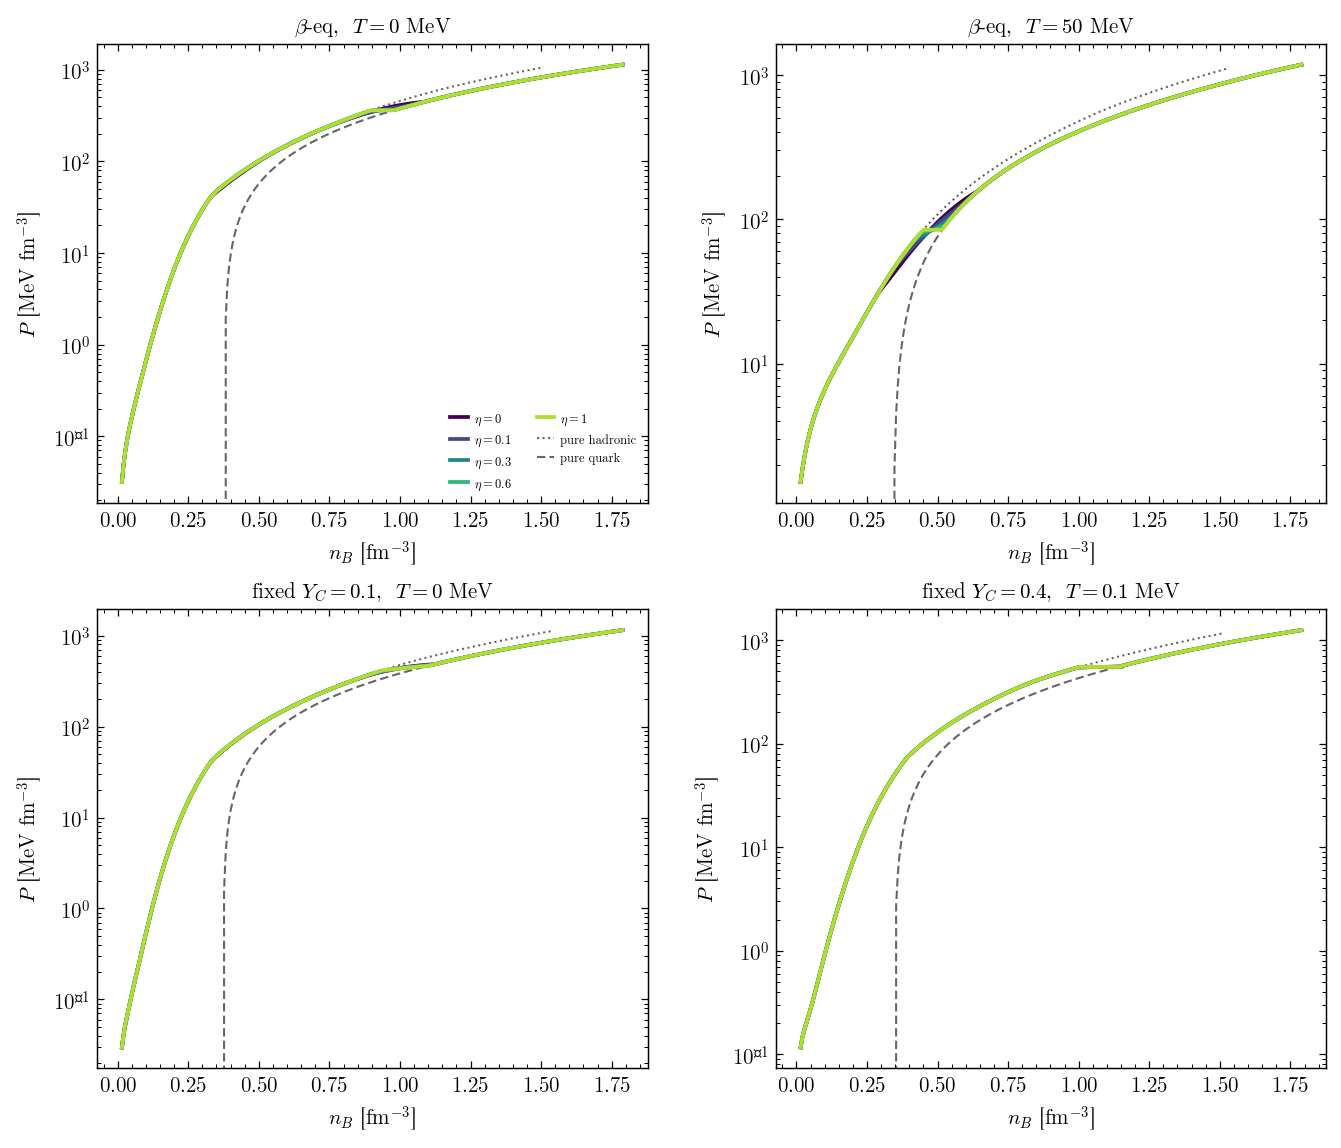

In [17]:
PANELS = [
    ("beta_eq_neutrinoless", {},            0.0),
    ("beta_eq_neutrinoless", {},           50.0),
    ("fixed_YC",             {"Y_C": 0.1},  0.0),
    ("fixed_YC",             {"Y_C": 0.4},  0.1),
]
LAYOUT = "2x2"
SHOW_PURE = True
LOG_P = True        # False to see the transition region on a linear scale

fig, axes = paper_grid(LAYOUT, mode="double", placeholder=False,
                       width=FIG_WIDTH, aspect=1.2)
for ax, (mode, fracs, T) in zip(axes.flat, PANELS):
    for eta in sorted(ETA_LIST):
        d = full_eos(mode, fracs, T, eta)
        if not d:
            continue
        ax.plot(d["n_B"], d["P"], "-", color=COLOR_OF[eta],
                label=rf"$\eta = {eta:g}$")

    if SHOW_PURE:
        key = pure_key(mode, fracs, T)
        for pure, style, lab in ((pure_hadronic.get(key), ":", "pure hadronic"),
                                 (pure_quark.get(key), (0, (4, 2)),
                                  "pure quark")):
            if pure is not None and pure["n_B"].size:
                ax.plot(pure["n_B"], pure["P"], ls=style, lw=1.0, zorder=0,
                        color=STANDARD_COLORS["Gray"], label=lab)

    ax.set_xlabel(LABELS["nB"])
    ax.set_ylabel(LABELS["P"])
    ax.set_title(panel_title(mode, fracs, T))
    if LOG_P:
        ax.set_yscale("log")

# One legend for the whole figure: every panel carries the same curves.
axes.flat[0].legend(fontsize=6, ncol=2, loc="lower right")
save_figure(fig, FIG_DIR / "fig01_P_vs_nB")
plt.show()

## III.2 Quark fraction against density

The same panels, showing χ instead. Flat at 0 is pure hadronic, rising is the mixed
phase, flat at 1 is pure quark — so this figure is the legend for every other one: it
says which segment of III.1 you are looking at.

The width of the rise is the whole story of η. At η = 0 (Gibbs) the two phases share
charge freely and χ climbs gradually over a wide density range; as η rises the charged
leptons are progressively tied to their own phase and the range narrows, until at η = 1
(Maxwell) it collapses to a jump and χ goes from 0 to 1 at a single density.

Saved: eos_tables_DD2vMIT/figures/fig02_chi_vs_nB.{png, pdf}


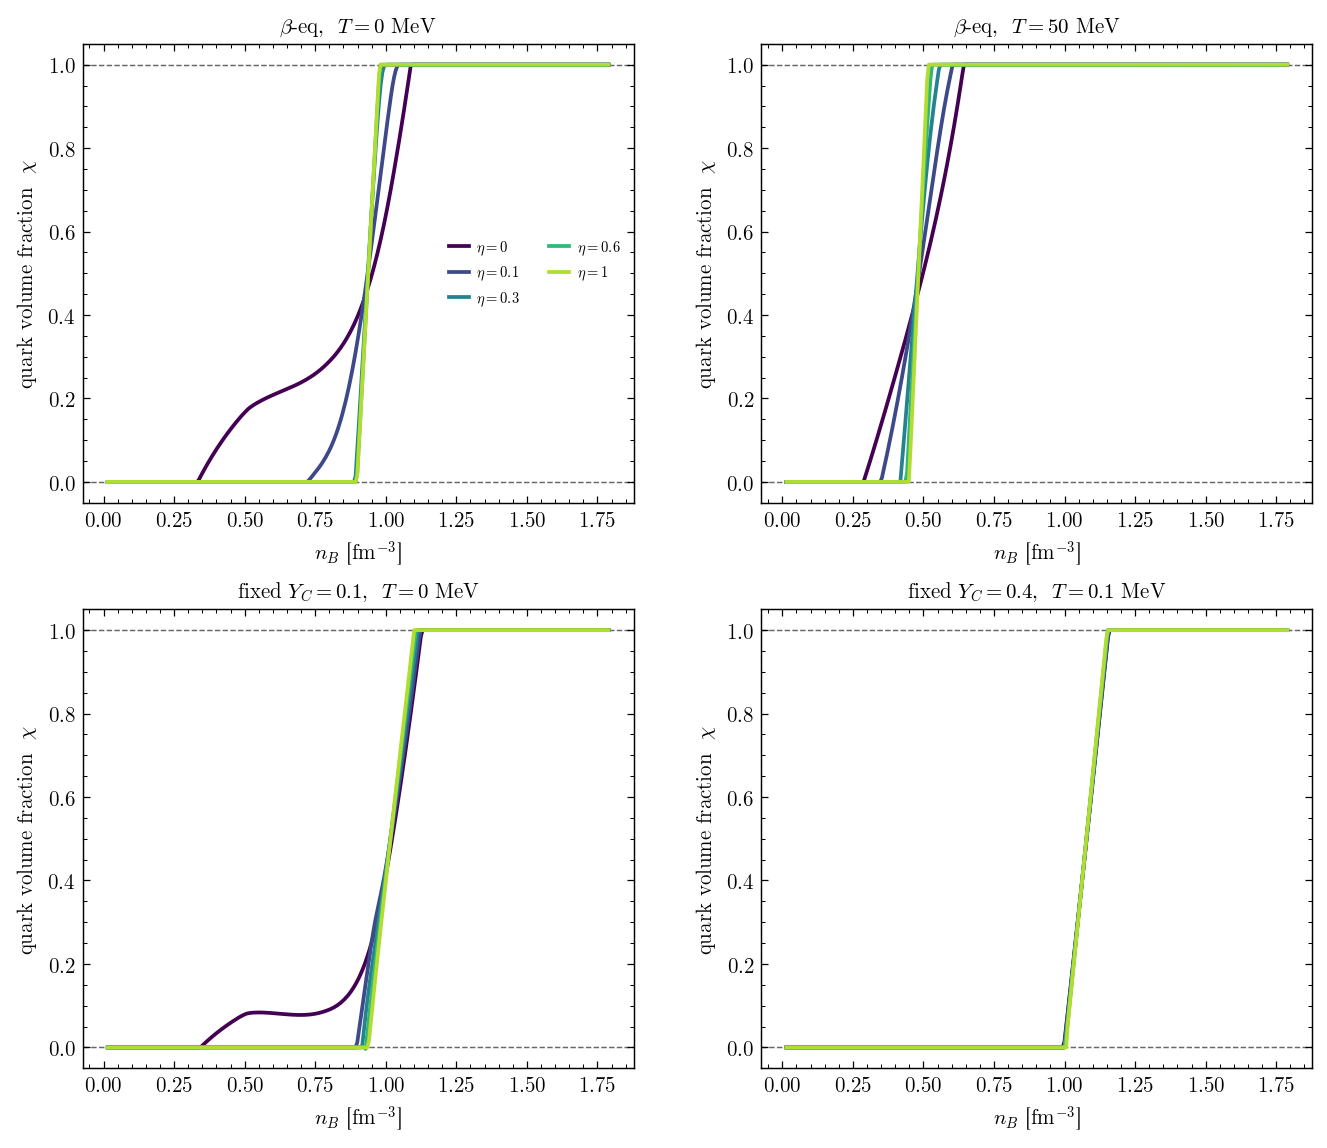

In [18]:
PANELS = [
    ("beta_eq_neutrinoless", {},            0.0),
    ("beta_eq_neutrinoless", {},           50.0),
    ("fixed_YC",             {"Y_C": 0.1},  0.0),
    ("fixed_YC",             {"Y_C": 0.4},  0.1),
]
LAYOUT = "2x2"

fig, axes = paper_grid(LAYOUT, mode="double", placeholder=False,
                       width=FIG_WIDTH, aspect=1.2)
for ax, (mode, fracs, T) in zip(axes.flat, PANELS):
    for eta in sorted(ETA_LIST):
        d = full_eos(mode, fracs, T, eta)
        if not d:
            continue
        ax.plot(d["n_B"], d["chi"], "-", color=COLOR_OF[eta],
                label=rf"$\eta = {eta:g}$")
    for y in (0.0, 1.0):
        ax.axhline(y, color=STANDARD_COLORS["Gray"], lw=0.7, ls="--", zorder=0)
    ax.set_xlabel(LABELS["nB"])
    ax.set_ylabel(r"quark volume fraction  $\chi$")
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(panel_title(mode, fracs, T))

axes.flat[0].legend(fontsize=7, ncol=2, loc="center right")
save_figure(fig, FIG_DIR / "fig02_chi_vs_nB")
plt.show()

## III.3 Mass-radius and tidal deformability

Cold, neutrinoless β-equilibrated stars built on the stitched core EOS, over the
observational credible regions. Both overlays come from
`eos.general.observational_constraints`, which reads contours precomputed offline and
shipped inside the package — nothing is refitted here — and both are drawn at low
`zorder` so the model curves stay on top.

The tidal panel carries the **per-component** (m, Λ) posteriors of GW170817 and
GW190425: two blobs per event, one per star, in one colour. Both components of a binary
share an equation of state, so a single Λ(M) curve has to thread through both blobs of
an event to be consistent with it. That is a different and stronger statement than the
Λ̃(M_chirp) contours often shown, which are a property of the binary and need a mass
ratio chosen before a single sequence can be compared against them.

Saved: eos_tables_DD2vMIT/figures/fig03_MR_and_tidal.{png, pdf}


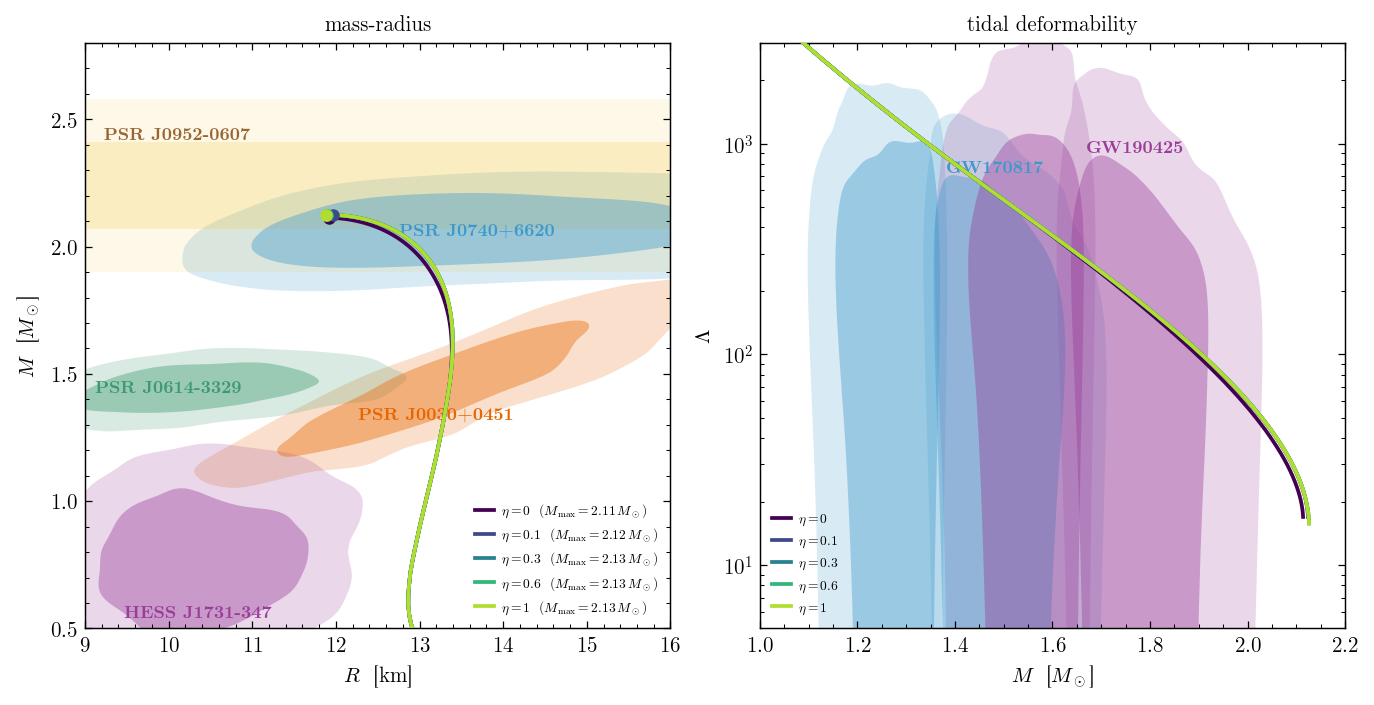

In [19]:
INLINE_LABELS = True

fig, axes = paper_grid("1x2", mode="double", placeholder=False,
                       width=FIG_WIDTH, aspect=1.0)
axMR, axL = axes[0]

# Constraints first, so the model curves are drawn over them.
add_observational_constraints(axMR, inline_labels=INLINE_LABELS)
add_tidal_constraints(axL, inline_labels=INLINE_LABELS)

for eta in sorted(tov):
    r = tov[eta]["results"]
    idx, _, M_max = find_mmax_precise(r)
    M, R, Lam = r[:idx + 1, 4], r[:idx + 1, 3], r[:idx + 1, 6]
    c = COLOR_OF.get(eta, STANDARD_COLORS["Gray"])
    axMR.plot(R, M, "-", color=c, zorder=4,
              label=rf"$\eta = {eta:g}$  ($M_{{\max}} = {M_max:.2f}\,M_\odot$)")
    axMR.plot(tov[eta]["R_Mmax"], M_max, "o", ms=5, color=c, zorder=5)
    axL.plot(M, Lam, "-", color=c, zorder=4, label=rf"$\eta = {eta:g}$")

axMR.set_xlabel(r"$R$  [km]")
axMR.set_ylabel(r"$M$  [$M_\odot$]")
axMR.set_title("mass-radius")
# Pin the frame: the constraint blobs would otherwise stretch the axes out to
# wherever the widest posterior reaches.
axMR.set_xlim(9.0, 16.0)
axMR.set_ylim(0.5, 2.8)
# Lower right: the lower-left corner is where the HESS blob and its inline
# label sit.
axMR.legend(fontsize=6.5, loc="lower right")

axL.set_xlabel(r"$M$  [$M_\odot$]")
axL.set_ylabel(r"$\Lambda$")
axL.set_title("tidal deformability")
axL.set_yscale("log")
axL.set_xlim(1.0, 2.2)
axL.set_ylim(5.0, 3e3)
axL.legend(fontsize=6.5, loc="lower left")

save_figure(fig, FIG_DIR / "fig03_MR_and_tidal")
plt.show()

## III.4 Phase boundaries in the (n_B, T) plane

For each η, the density at which the quark phase appears (χ = 0, onset) and the one at
which the hadronic phase disappears (χ = 1, offset), against temperature. The shaded
band between them is the mixed phase: wide and Gibbs-like at η = 0, narrowing as the
charged leptons are tied to their own phase, and collapsing to the Maxwell density jump
at η = 1.

The grey contours are lines of **constant entropy per baryon**. They are what a
supernova core or a merger remnant actually moves along — those are close to adiabatic,
not isothermal — so reading the phase diagram along an iso-S line rather than
horizontally tells you whether a collapsing or merging star crosses the transition at
all. They are built by contouring `S_per_B` from the tables already on disk, which is
why they cost nothing; they are drawn for `ETA_ISO` alone, since outside the window they
do not depend on η and inside it they shift by less than the line width.

A panel whose curves stop short is one where the higher temperatures did not complete —
check `completeness.csv` from II.2 before reading anything into where a boundary ends.

Saved: eos_tables_DD2vMIT/figures/fig04_boundaries_nB_T.{png, pdf}


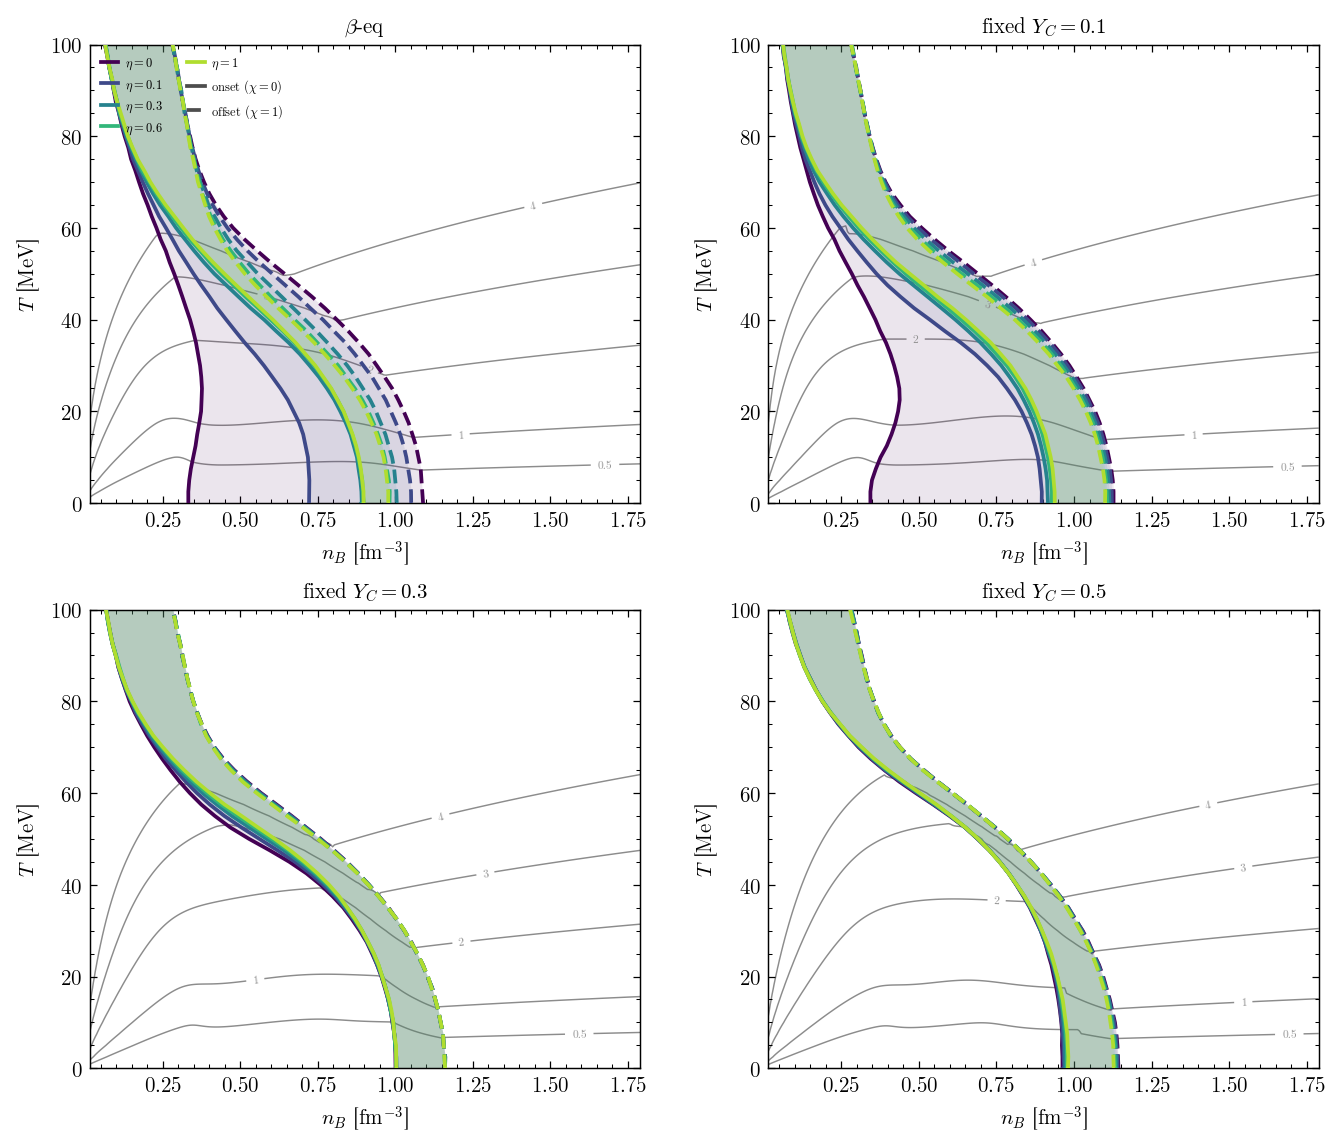

In [20]:
PANELS = [
    ("beta_eq_neutrinoless", {}),
    ("fixed_YC",             {"Y_C": 0.1}),
    ("fixed_YC",             {"Y_C": 0.3}),
    ("fixed_YC",             {"Y_C": 0.5}),
]
LAYOUT = "2x2"
ISO_S = [0.5, 1.0, 2.0, 3.0, 4.0]     # entropy per baryon, k_B
ETA_ISO = 0.0                          # the eta the iso-S contours are drawn for

fig, axes = paper_grid(LAYOUT, mode="double", placeholder=False,
                       width=FIG_WIDTH, aspect=1.2)
for ax, (mode, fracs) in zip(axes.flat, PANELS):
    # ---- iso-entropy contours, underneath everything else -----------------
    S = np.full((len(T_LIST), len(NB)), np.nan)
    for i, T in enumerate(T_LIST):
        d = full_eos(mode, fracs, T, ETA_ISO)
        if d and d["n_B"].size > 2:
            S[i] = np.interp(NB, d["n_B"], d["S_per_B"],
                             left=np.nan, right=np.nan)
    if np.isfinite(S).any():
        cs = ax.contour(NB, T_LIST, S, levels=ISO_S, colors="0.55",
                        linewidths=0.7, zorder=1)
        ax.clabel(cs, fmt="%g", fontsize=5.5, inline=True)

    # ---- the two boundaries, one colour per eta ---------------------------
    for eta in sorted(ETA_LIST):
        bounds = np.array([window_of(mode, fracs, T, eta) for T in T_LIST])
        onset, offset = bounds[:, 0], bounds[:, 1]
        good = np.isfinite(onset) & np.isfinite(offset)
        if not good.any():
            continue
        c = COLOR_OF[eta]
        Ts = np.asarray(T_LIST, dtype=float)
        ax.plot(onset[good], Ts[good], "-", color=c, zorder=3,
                label=rf"$\eta = {eta:g}$")
        ax.plot(offset[good], Ts[good], "--", color=c, zorder=3)
        ax.fill_betweenx(Ts[good], onset[good], offset[good], color=c,
                         alpha=0.10, lw=0, zorder=2)

    ax.set_xlabel(LABELS["nB"])
    ax.set_ylabel(LABELS["T"])
    ax.set_title(panel_title(mode, fracs))

# Two grey proxies say what solid and dashed mean without a legend title,
# which at this width wraps over the entries.
axes.flat[0].plot([], [], "-", color="0.3", label=r"onset ($\chi = 0$)")
axes.flat[0].plot([], [], "--", color="0.3", label=r"offset ($\chi = 1$)")
axes.flat[0].legend(fontsize=6, ncol=2, loc="upper left")
save_figure(fig, FIG_DIR / "fig04_boundaries_nB_T")
plt.show()

## III.5 Phase boundaries in the (μ_B, T) plane

The same boundaries against baryon chemical potential rather than density — the plane a
QCD phase diagram is normally drawn in, and the one in which the two constructions look
most different.

**At η = 1 the two curves collapse onto one.** That is the Maxwell construction, not a
bug: imposing local charge neutrality in each phase leaves μ_B (and P) equal across the
interface, so the coexistence region is a *line* in (μ_B, T) even though it is a finite
band in (n_B, T). At η < 1 the phases exchange charge and μ_B varies across the window,
so the band reopens. Comparing this figure with III.4 is the cleanest way to see that
the width of a mixed phase is a statement about density, not about chemical potential.

The boundary values are read off the first and last converged row of each window in the
saved tables, so a window sampled with holes at its edges reports slightly inside its
true boundary. `completeness.csv` says which those are.

Saved: eos_tables_DD2vMIT/figures/fig05_boundaries_muB_T.{png, pdf}


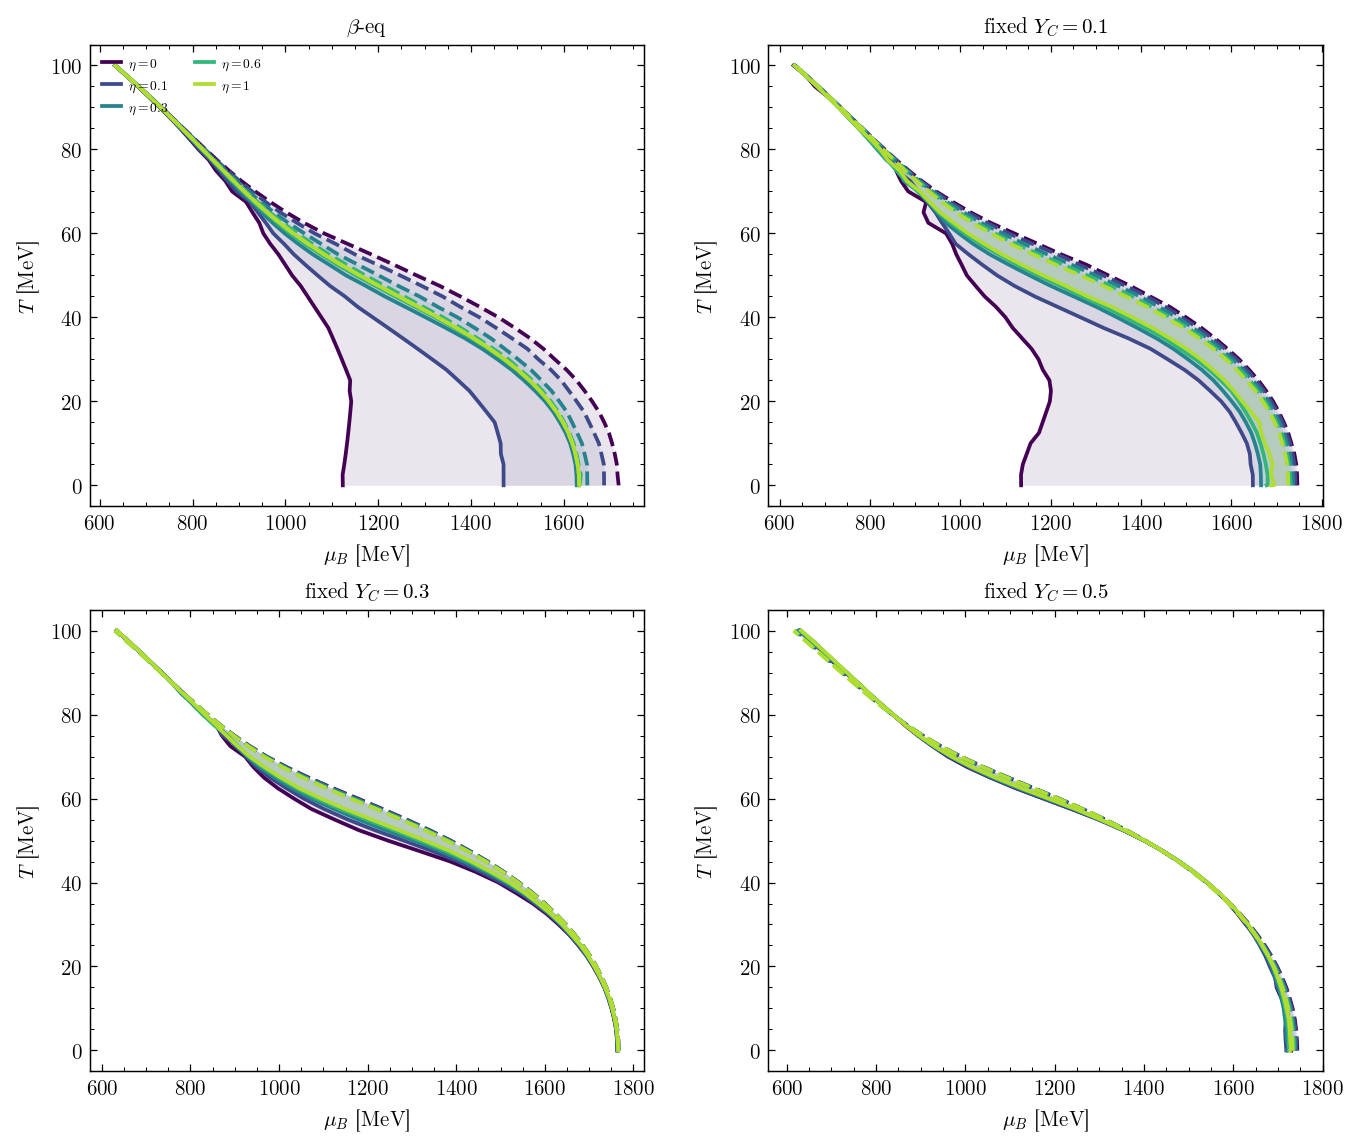

In [21]:
PANELS = [
    ("beta_eq_neutrinoless", {}),
    ("fixed_YC",             {"Y_C": 0.1}),
    ("fixed_YC",             {"Y_C": 0.3}),
    ("fixed_YC",             {"Y_C": 0.5}),
]
LAYOUT = "2x2"


def mu_boundaries(mode, fracs, T, eta):
    """(mu_B at the onset, mu_B at the offset) for one slice, or (nan, nan).

    The mixed table holds exactly the window, so its first and last rows in
    density ARE the two boundaries.
    """
    d = slice_at(loaded.get(mode, {}).get(eta, {}), T, fracs)
    if not d or d["n_B"].size == 0:
        return np.nan, np.nan
    return float(d["mu_B"][0]), float(d["mu_B"][-1])


fig, axes = paper_grid(LAYOUT, mode="double", placeholder=False,
                       width=FIG_WIDTH, aspect=1.2)
for ax, (mode, fracs) in zip(axes.flat, PANELS):
    for eta in sorted(ETA_LIST):
        bounds = np.array([mu_boundaries(mode, fracs, T, eta) for T in T_LIST])
        lo, hi = bounds[:, 0], bounds[:, 1]
        good = np.isfinite(lo) & np.isfinite(hi)
        if not good.any():
            continue
        c = COLOR_OF[eta]
        Ts = np.asarray(T_LIST, dtype=float)
        ax.plot(lo[good], Ts[good], "-", color=c, zorder=3,
                label=rf"$\eta = {eta:g}$")
        ax.plot(hi[good], Ts[good], "--", color=c, zorder=3)
        ax.fill_betweenx(Ts[good], lo[good], hi[good], color=c, alpha=0.10,
                         lw=0, zorder=2)

    ax.set_xlabel(LABELS["mu_B"])
    ax.set_ylabel(LABELS["T"])
    ax.set_title(panel_title(mode, fracs))

axes.flat[0].legend(fontsize=6.5, ncol=2, loc="upper left")
save_figure(fig, FIG_DIR / "fig05_boundaries_muB_T")
plt.show()

## III.6 Composition through the transition

Particle fractions from the corresponding densities: Y_h = (1−χ) n_h^H / n_B for the
hadrons and Y_q = χ n_q^Q / n_B for the quarks, so the curves sum consistently across
the mixed phase. Colour is the particle and linestyle the multiplet — nucleons solid,
hyperons dashed, Δ dash-dot, quarks densely dashed, leptons dotted — so the figure
survives being printed in black and white.

`PANELS` entries here carry an η as well, because composition is the one place where η
acts visibly: it decides how much charge each phase has to carry on its own, and
therefore how the proton and the electron fractions behave through the window.

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

Saved: eos_tables_DD2vMIT/figures/fig06_composition.{png, pdf}


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


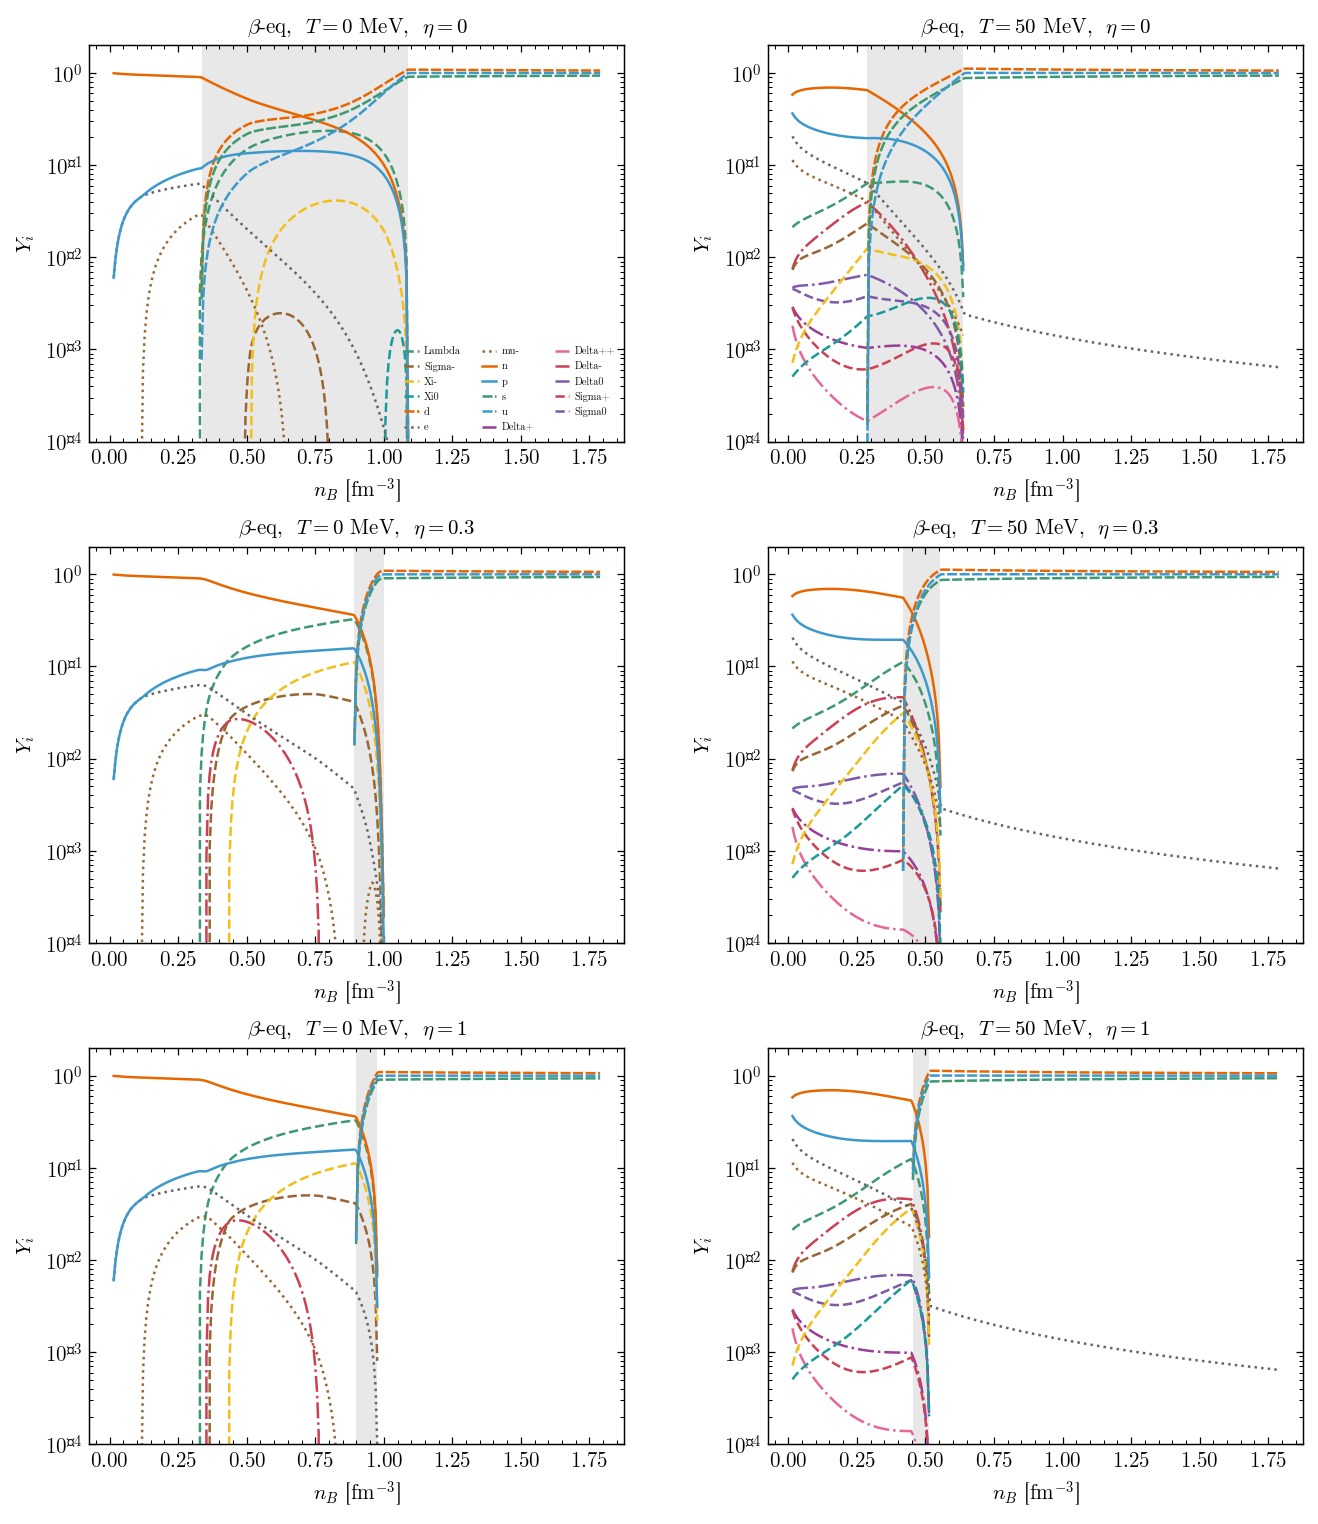

In [22]:
PANELS = [
    ("beta_eq_neutrinoless", {},  0.0, 0.0),
    ("beta_eq_neutrinoless", {}, 50.0, 0.0),
    ("beta_eq_neutrinoless", {},  0.0, 0.3),
    ("beta_eq_neutrinoless", {}, 50.0, 0.3),
    ("beta_eq_neutrinoless", {},  0.0, 1.0),
    ("beta_eq_neutrinoless", {}, 50.0, 1.0),
]
LAYOUT = "3x2"

fig, axes = paper_grid(LAYOUT, mode="double", placeholder=False,
                       width=FIG_WIDTH, aspect=1.35)
for ax, (mode, fracs, T, eta) in zip(axes.flat, PANELS):
    d = full_eos(mode, fracs, T, eta)
    if not d:
        ax.set_title(panel_title(mode, fracs, T, eta) + "  — no data")
        continue

    # Only the species that actually appear: a curve pinned at the floor is
    # noise, and with hyperons and Deltas on there are two dozen of them.
    species = sorted(k[2:] for k in d if k.startswith("Y_")
                     and k[2:] not in ("C", "S", "B_H", "B_Q", "C_H", "C_Q",
                                       "S_H", "S_Q", "L_H", "L_Q", "L_G"))
    for sp in species:
        y = d[f"Y_{sp}"]
        if not np.isfinite(y).any() or np.nanmax(y) < Y_FLOOR:
            continue
        colour, style = particle_style(sp)
        ax.plot(d["n_B"], y, ls=style, lw=1.2, color=colour, label=sp)

    mixed = (d["chi"] > 0.0) & (d["chi"] < 1.0)
    if mixed.any():
        ax.axvspan(d["n_B"][mixed].min(), d["n_B"][mixed].max(),
                   color=STANDARD_COLORS["Gray"], alpha=0.15, lw=0, zorder=0)

    ax.set_yscale("log")
    ax.set_ylim(Y_FLOOR, 2.0)
    ax.set_xlabel(LABELS["nB"])
    ax.set_ylabel(LABELS["Y_i"])
    ax.set_title(panel_title(mode, fracs, T, eta))

# One legend for the figure, built from the union of what the panels drew:
# a species below the floor in the first panel can still dominate a hotter one,
# and a legend taken from panel (a) alone would silently omit it.
handles = {}
for ax in axes.flat:
    for h, lab in zip(*ax.get_legend_handles_labels()):
        handles.setdefault(lab, h)
axes.flat[0].legend(handles.values(), handles.keys(), fontsize=5, ncol=3,
                    loc="lower right")
save_figure(fig, FIG_DIR / "fig06_composition")
plt.show()

## III.7 Where each conserved charge sits

The same six panels, but resolved by *charge* rather than by species: baryon number,
electric charge (non-leptonic), strangeness and lepton number, each split into the part
carried by the hadronic phase, the part carried by the quark phase, and the total.

This is the figure η is really about. Charge neutrality has to hold for the system;
whether it holds *phase by phase* is what η sets. So at η = 0 the Y_C curves of the two
phases separate strongly through the window — the hadronic phase runs positive and the
quark phase compensates — while at η = 1 they are each pinned to the neutralising lepton
density in their own phase and barely separate at all. Y_B is the check: the two parts
always sum to 1.

Lepton number splits three ways rather than two, because the local populations belong to
a phase and the global one does not. In the pure wings the leptons are assigned to the
phase that is present, which makes the curves continuous into a Maxwell window and makes
them step at the edges of a Gibbs one — at η = 0 the leptons genuinely are a background
belonging to neither phase, and that step is the statement of it.

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Saved: eos_tables_DD2vMIT/figures/fig07_charges_by_phase.{png, pdf}


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


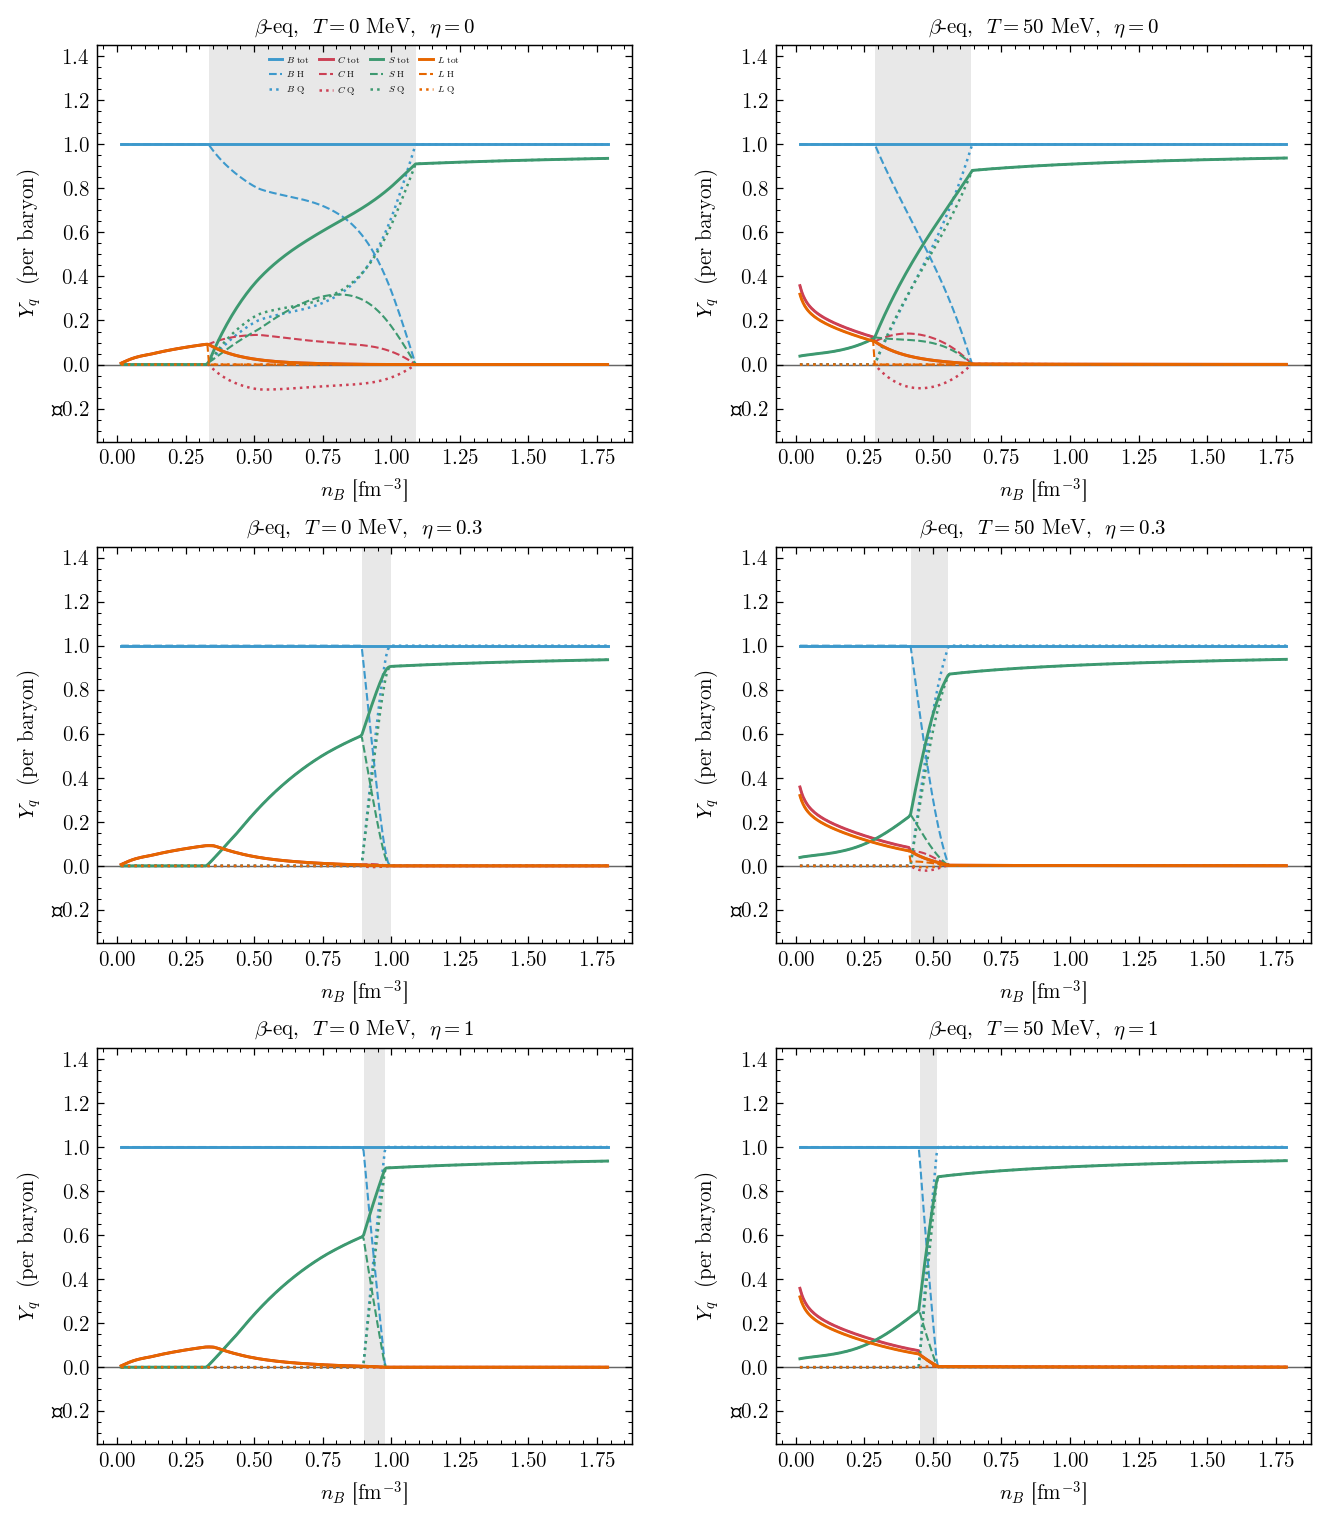

In [23]:
PANELS = [
    ("beta_eq_neutrinoless", {},  0.0, 0.0),
    ("beta_eq_neutrinoless", {}, 50.0, 0.0),
    ("beta_eq_neutrinoless", {},  0.0, 0.3),
    ("beta_eq_neutrinoless", {}, 50.0, 0.3),
    ("beta_eq_neutrinoless", {},  0.0, 1.0),
    ("beta_eq_neutrinoless", {}, 50.0, 1.0),
]
LAYOUT = "3x2"
# charge -> (latex, colour). Drop an entry to declutter the panel.
CHARGES = {
    "B": (r"$B$", STANDARD_COLORS["Blue"]),
    "C": (r"$C$", STANDARD_COLORS["Red"]),
    "S": (r"$S$", STANDARD_COLORS["Green"]),
    "L": (r"$L$", STANDARD_COLORS["Orange"]),
}

fig, axes = paper_grid(LAYOUT, mode="double", placeholder=False,
                       width=FIG_WIDTH, aspect=1.35)
for ax, (mode, fracs, T, eta) in zip(axes.flat, PANELS):
    d = full_eos(mode, fracs, T, eta)
    if not d:
        ax.set_title(panel_title(mode, fracs, T, eta) + "  — no data")
        continue

    for q, (tex, colour) in CHARGES.items():
        H = d.get(f"Y_{q}_H")
        Q = d.get(f"Y_{q}_Q")
        if H is None or Q is None:
            continue
        # Lepton number also has the global population, which belongs to
        # neither phase but does count towards the total.
        G = d.get("Y_L_G", 0.0) if q == "L" else 0.0
        total = np.nan_to_num(H) + np.nan_to_num(Q) + np.nan_to_num(G)
        ax.plot(d["n_B"], total, "-", lw=1.4, color=colour, label=f"{tex} tot")
        ax.plot(d["n_B"], H, "--", lw=1.0, color=colour, label=f"{tex} H")
        ax.plot(d["n_B"], Q, ":", lw=1.2, color=colour, label=f"{tex} Q")

    mixed = (d["chi"] > 0.0) & (d["chi"] < 1.0)
    if mixed.any():
        ax.axvspan(d["n_B"][mixed].min(), d["n_B"][mixed].max(),
                   color=STANDARD_COLORS["Gray"], alpha=0.15, lw=0, zorder=0)
    ax.axhline(0.0, color=STANDARD_COLORS["Gray"], lw=0.7, zorder=0)

    ax.set_xlabel(LABELS["nB"])
    ax.set_ylabel(r"$Y_q$  (per baryon)")
    ax.set_title(panel_title(mode, fracs, T, eta))
    # Headroom above Y_B = 1 for the legend, and below 0 for the negative
    # quark-phase charge that a Gibbs window produces.
    ax.set_ylim(-0.35, 1.45)

axes.flat[0].legend(fontsize=4.5, ncol=4, loc="upper center", columnspacing=1.0)
save_figure(fig, FIG_DIR / "fig07_charges_by_phase")
plt.show()

## III.8 The two sound speeds

The clearest single picture of what η does.

**c_eq² = dP/dε** (dashed) is taken along the equilibrium sequence, where χ is free to
readjust. A compression is then answered by converting hadrons into quarks instead of by
raising the pressure, so c_eq **dips** through a Gibbs window and **collapses to zero**
through a Maxwell one, where the pressure is constant by construction. This is the sound
speed that enters the TOV equations.

**c_ad² (frozen, solid)** holds χ fixed — the mixture is compressed faster than one phase
can convert into the other — so the pressure has to rise and c_ad does *not* collapse.
Freezing χ is the part that matters; freezing only the charge fractions would let the
solve slide back onto the plateau. It is defined only where two phases coexist, so it is
drawn across the window alone.

The gap between the two is what a composition g-mode would measure: the Brunt-Väisälä
frequency is proportional to (1/c_eq² − 1/c_ad²), so it vanishes identically wherever
these two curves coincide and spikes wherever they separate.

`frozen_along` re-solves both phases twice per point, so this is the only expensive cell
in Part III — budget a few seconds per (panel, η).

Saved: eos_tables_DD2vMIT/figures/fig08_sound_speeds.{png, pdf}


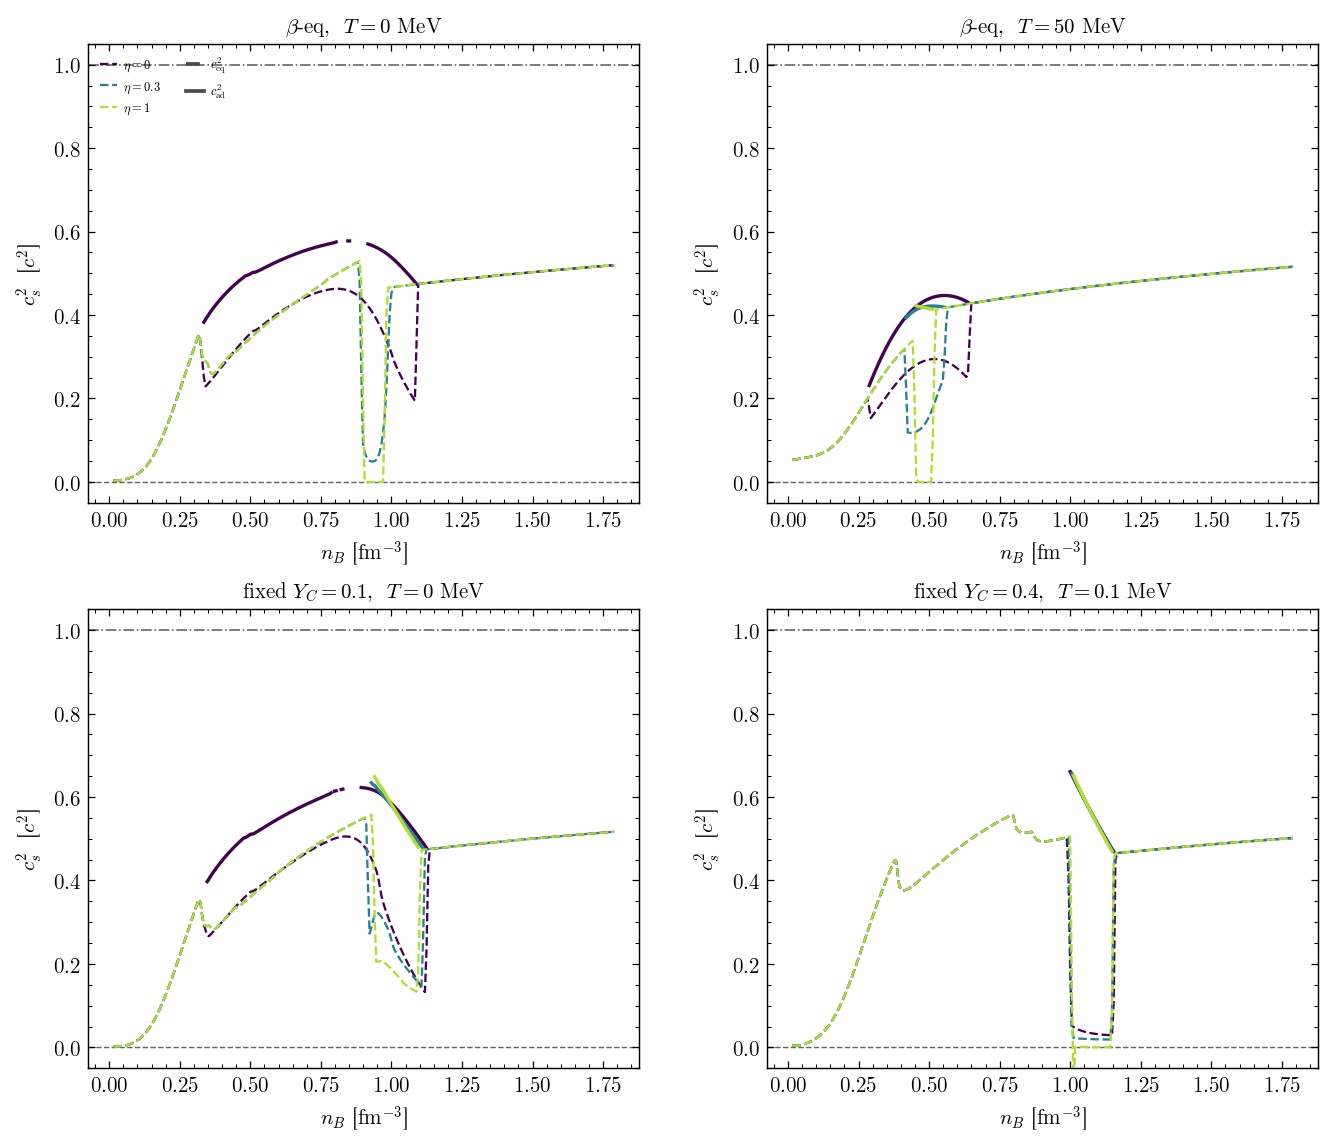

(10.8 s)


In [24]:
PANELS = [
    ("beta_eq_neutrinoless", {},            0.0),
    ("beta_eq_neutrinoless", {},           50.0),
    ("fixed_YC",             {"Y_C": 0.1},  0.0),
    ("fixed_YC",             {"Y_C": 0.4},  0.1),
]
LAYOUT = "2x2"
CS_ETAS = [e for e in (0.0, 0.3, 1.0) if e in ETA_LIST]   # subset: this is slow


def spec_of(mode, fracs):
    """The ChargeSpec one PANELS entry describes."""
    if mode == "beta_eq_neutrinoless":
        return beta_eq_neutrinoless()
    if mode == "fixed_YC":
        return fixed_YC(fracs["Y_C"], leptons=True)
    raise NotImplementedError(f"no ChargeSpec wired for mode {mode!r}")


t0 = time.time()
fig, axes = paper_grid(LAYOUT, mode="double", placeholder=False,
                       width=FIG_WIDTH, aspect=1.2)
for ax, (mode, fracs, T) in zip(axes.flat, PANELS):
    spec = spec_of(mode, fracs)
    for eta in CS_ETAS:
        c = COLOR_OF.get(eta, STANDARD_COLORS["Gray"])

        # Equilibrium: straight off the stitched table built in Part II, which
        # already carries the right wings for THIS mode. (build_mixed_eos_table
        # would rebuild them in beta equilibrium, which is only correct for the
        # beta-eq panels.)
        d = full_eos(mode, fracs, T, eta)
        if d and d["n_B"].size > 3:
            ax.plot(d["n_B"], sound_speed_eq(d["P"], d["eps"]), "--", lw=1.1,
                    color=c, label=rf"$\eta = {eta:g}$")

        # Frozen: only defined where there are two phases.
        n_lo, n_hi = window_of(mode, fracs, T, eta)
        if not (np.isfinite(n_lo) and np.isfinite(n_hi)):
            continue
        inside = NB[(NB >= n_lo) & (NB <= n_hi)]
        if inside.size < 3:
            continue
        rs = sweep_mixed(PAR, FLAGS, inside, eta, spec, vmit_params=VMIT, T=T)
        if not rs:
            continue
        ax.plot([r.n_B for r in rs],
                frozen_along(PAR, FLAGS, rs, vmit_params=VMIT), "-", lw=1.6,
                color=c)

    ax.axhline(1.0, color=STANDARD_COLORS["Gray"], lw=0.8, ls="-.", zorder=0)
    ax.axhline(0.0, color=STANDARD_COLORS["Gray"], lw=0.7, ls="--", zorder=0)
    ax.set_xlabel(LABELS["nB"])
    ax.set_ylabel(r"$c_s^2$  [$c^2$]")
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(panel_title(mode, fracs, T))

# Grey proxies for the two line styles, rather than a legend title, which at
# this width wraps over the entries.
axes.flat[0].plot([], [], "--", color="0.3", label=r"$c_{\rm eq}^2$")
axes.flat[0].plot([], [], "-", color="0.3", label=r"$c_{\rm ad}^2$")
axes.flat[0].legend(fontsize=6, ncol=2, loc="upper left")
save_figure(fig, FIG_DIR / "fig08_sound_speeds")
plt.show()
print(f"({time.time()-t0:.1f} s)")

## III.9 Rotation

Uniformly rotating, axisymmetric models of the *same* stitched EOSs Part II.3 integrated,
computed with the Komatsu-Eriguchi-Hachisu self-consistent field method as implemented
in RNS (Stergioulas & Friedman 1995, ApJ 444, 306), driven through `eos.tov.rotating`.

**Read this before trusting a number.** `rotating_grid` never asks the solver for a
physical target directly. It scans the axis ratio r_p/r_e — where every model converges —
and inverts the resulting curve in Python, because M, M_0, Ω and J are all monotone in
r_p/r_e at fixed central density. Two consequences: one scan answers every target, so
adding isolines is free; and the values on the isolines are **interpolated between
converged models**, not themselves converged models. Call `rotating_model` for a point
that has to be exact.

**Why the constant-M_0 panel is the physically interesting one.** A real star spins down
at fixed *baryon* number, not at fixed gravitational mass, so a constant-M_0 curve is the
track it actually follows. Where such a curve turns over, the star has run out of stable
configurations and collapses: that is the supramassive branch, and its extent is set by
how much of the mixed phase sits inside the star.

A target beyond the Keplerian limit of its central density comes back as NaN rather than
an error, which is why the fastest isolines simply stop at low n_B,c — those stars cannot
spin that fast without shedding mass at the equator.

In [25]:
# Baryonic masses [M_sun] for panel (d). A target outside the M_0 range a given
# central density can reach comes back NaN, so pick values near the static M_0
# spanned by ROT_NB_C: M_0 runs ~10-20% above the gravitational mass, so
# n_B,c = 0.4-1.6 fm^-3 here reaches roughly M_0 = 1.6-2.9.
ROT_M0 = [1.8, 2.1, 2.4, 2.7]

rot_kepler, rot_iso = {}, {}
if not have_rns():
    print("No `rns` executable found — III.9 skipped.\n"
          "eos.tov.rns_backend.find_rns_binary() looks on PATH and at the usual\n"
          "build locations; point it at your build or pass rns_path= to run it.")
else:
    for eta in TOV_ETAS:
        t0 = time.time()
        core = tov[eta]["core"]
        eos_rot = core.to_tov()
        # The solver is parametrised by central ENERGY density; the figures want
        # central BARYON density, so map across on the table that produced both.
        e_c = np.interp(ROT_NB_C, core.n_B, core.eps)
        rot_kepler[eta] = kepler_sequence(eos_rot, e_c, parallel=True)

        extra = ""
        if eta == ROT_ETA_SHOW:
            # Only the displayed eta needs the isolines; every eta needs its
            # Keplerian limit for III.9b.
            rot_iso["freq"] = rotating_grid(eos_rot, e_c, freq_grid=ROT_FREQ,
                                            n_scan=ROT_N_SCAN, parallel=True)
            rot_iso["M_0"] = rotating_grid(eos_rot, e_c, M_0_grid=ROT_M0,
                                           n_scan=ROT_N_SCAN, parallel=True)
            extra = (f"  (+{len(ROT_FREQ)} frequency and {len(ROT_M0)} "
                     f"baryonic-mass sequences)")

        M_kep = np.nanmax(rot_kepler[eta][:, KEPLER_COLUMNS.index("M")])
        f_kep = np.nanmax(rot_kepler[eta][:, KEPLER_COLUMNS.index("freq")])
        print(f"eta={eta}: M_max^Kepler={M_kep:.3f} Msun  "
              f"M_max^TOV={tov[eta]['M_max']:.3f} Msun  "
              f"ratio={M_kep / tov[eta]['M_max']:.3f}  "
              f"f_K(max)={f_kep:.0f} Hz | {time.time() - t0:.1f} s{extra}",
              flush=True)

eta=0.0: M_max^Kepler=2.562 Msun  M_max^TOV=2.114 Msun  ratio=1.212  f_K(max)=1650 Hz | 68.9 s  (+4 frequency and 4 baryonic-mass sequences)
eta=0.1: M_max^Kepler=2.577 Msun  M_max^TOV=2.124 Msun  ratio=1.214  f_K(max)=1644 Hz | 12.6 s
eta=0.3: M_max^Kepler=2.578 Msun  M_max^TOV=2.126 Msun  ratio=1.213  f_K(max)=1643 Hz | 11.1 s
eta=0.6: M_max^Kepler=2.578 Msun  M_max^TOV=2.126 Msun  ratio=1.213  f_K(max)=1643 Hz | 11.0 s
eta=1.0: M_max^Kepler=2.578 Msun  M_max^TOV=2.126 Msun  ratio=1.213  f_K(max)=1643 Hz | 10.4 s


Saved: eos_tables_DD2vMIT/figures/fig09_rotation.{png, pdf}


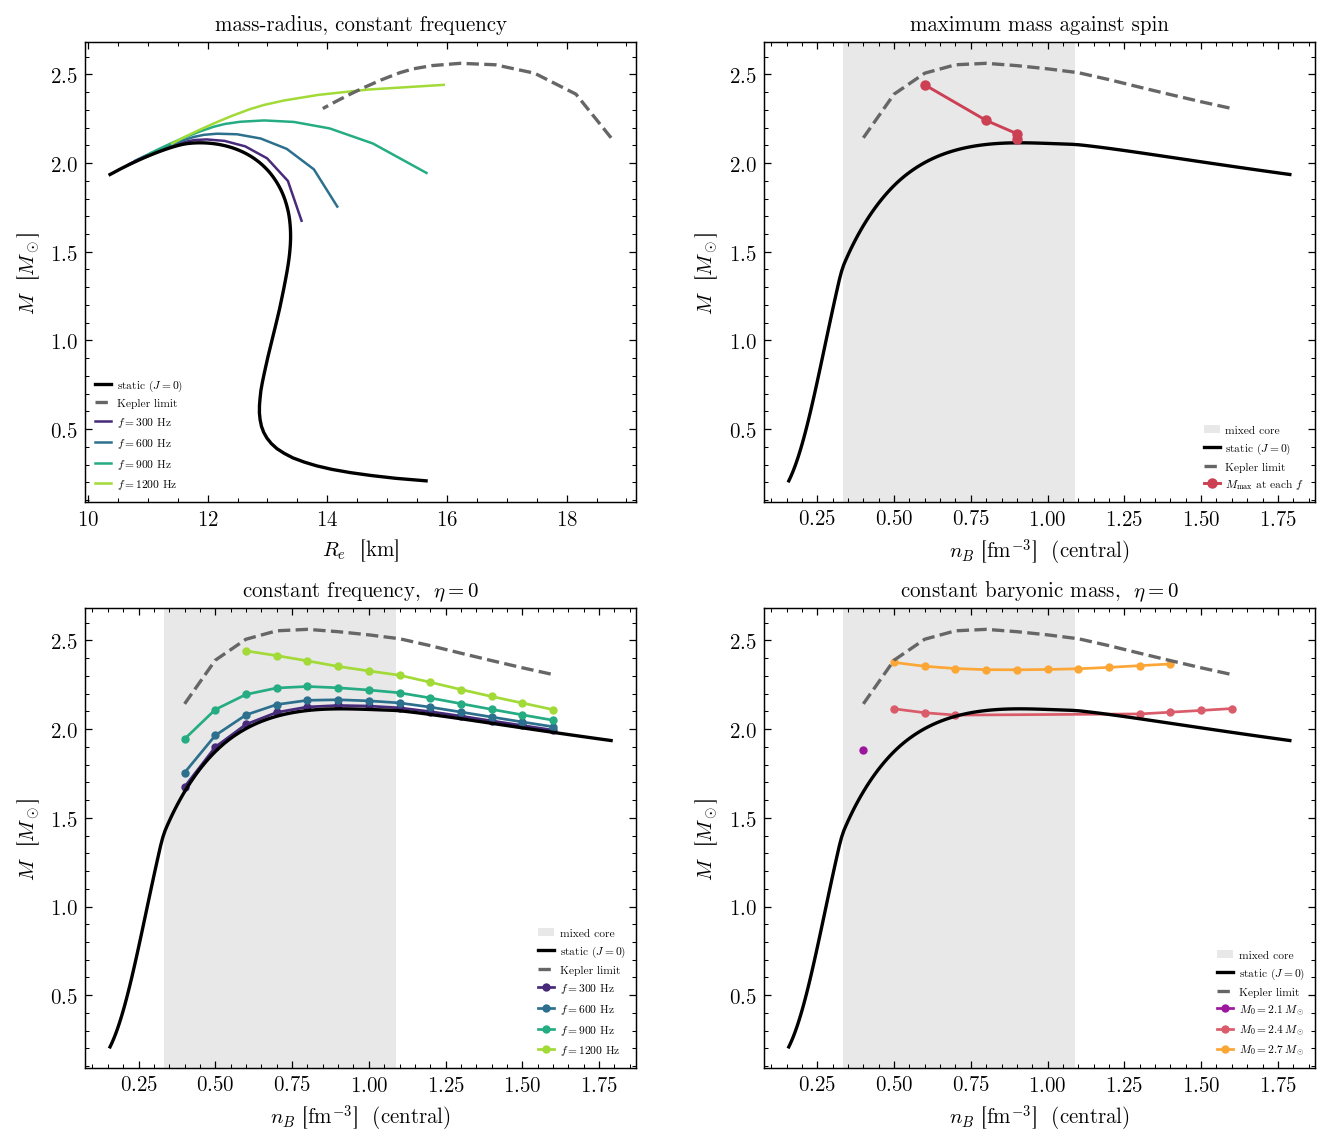

In [26]:
if rot_iso:
    ICOL = {c: k for k, c in enumerate(GRID_COLUMNS)}
    KCOL = {c: k for k, c in enumerate(KEPLER_COLUMNS)}
    core = tov[ROT_ETA_SHOW]["core"]
    static = tov[ROT_ETA_SHOW]["results"]      # columns e_c, n_c, P_c, R, M, ...
    kep = rot_kepler[ROT_ETA_SHOW]
    f_grid = rot_iso["freq"].reshape(len(ROT_NB_C), len(ROT_FREQ), -1)
    m0_grid = rot_iso["M_0"].reshape(len(ROT_NB_C), len(ROT_M0), -1)

    fig, axes = paper_grid("2x2", mode="double", placeholder=False,
                           width=FIG_WIDTH, aspect=1.2)
    axMR, axNB, axF, axM0 = axes.flat
    f_shades = plt.cm.viridis(np.linspace(0.12, 0.86, len(ROT_FREQ)))
    m0_shades = plt.cm.plasma(np.linspace(0.10, 0.80, len(ROT_M0)))

    def _mixed_span(ax):
        """Shade the central densities that give a mixed core. It is in CENTRAL
        density, so a star to the right of the band has a pure quark core, not
        no quark core."""
        if core.has_transition:
            ax.axvspan(core.n_onset, core.n_offset,
                       color=STANDARD_COLORS["Gray"], alpha=0.15, lw=0,
                       zorder=0, label="mixed core")

    # (a) mass-radius: the static and Keplerian curves bound the family.
    axMR.plot(static[:, 3], static[:, 4], color="black", lw=1.6, zorder=5,
              label=r"static ($J=0$)")
    axMR.plot(kep[:, KCOL["R_e"]], kep[:, KCOL["M"]],
              color=STANDARD_COLORS["Gray"], lw=1.6, ls="--", zorder=5,
              label="Kepler limit")
    for k, f in enumerate(ROT_FREQ):
        M, R = f_grid[:, k, ICOL["M"]], f_grid[:, k, ICOL["R_e"]]
        good = np.isfinite(M) & np.isfinite(R)
        if good.any():
            axMR.plot(R[good], M[good], "-", lw=1.2, color=f_shades[k],
                      zorder=4, label=rf"$f = {f:g}$ Hz")
    axMR.set_xlabel(r"$R_e$  [km]")
    axMR.set_ylabel(r"$M$  [$M_\odot$]")
    axMR.set_title("mass-radius, constant frequency")
    axMR.legend(fontsize=5.5, loc="lower left")

    # (b) M against central density, with the locus of the rotating maxima.
    _mixed_span(axNB)
    axNB.plot(static[:, 1], static[:, 4], color="black", lw=1.6, zorder=5,
              label=r"static ($J=0$)")
    axNB.plot(ROT_NB_C, kep[:, KCOL["M"]], color=STANDARD_COLORS["Gray"],
              lw=1.6, ls="--", zorder=5, label="Kepler limit")
    peak_nb, peak_M = [], []
    for k in range(len(ROT_FREQ)):
        M = f_grid[:, k, ICOL["M"]]
        if np.isfinite(M).any():
            i = int(np.nanargmax(M))
            peak_nb.append(ROT_NB_C[i])
            peak_M.append(M[i])
    if peak_nb:
        axNB.plot(peak_nb, peak_M, "o-", ms=4, lw=1.4, zorder=6,
                  color=STANDARD_COLORS["Red"],
                  label=r"$M_{\max}$ at each $f$")
    axNB.set_xlabel(LABELS["nB"] + "  (central)")
    axNB.set_ylabel(r"$M$  [$M_\odot$]")
    axNB.set_title("maximum mass against spin")
    axNB.legend(fontsize=5.5, loc="lower right")

    # (c) constant frequency, (d) constant baryonic mass.
    for ax, key, targets, shades, fmt, title in (
            (axF, "freq", ROT_FREQ, f_shades, lambda v: rf"$f = {v:g}$ Hz",
             "constant frequency"),
            (axM0, "M_0", ROT_M0, m0_shades,
             lambda v: rf"$M_0 = {v:g}\,M_\odot$",
             "constant baryonic mass")):
        grid = f_grid if key == "freq" else m0_grid
        _mixed_span(ax)
        ax.plot(static[:, 1], static[:, 4], color="black", lw=1.6, zorder=5,
                label=r"static ($J=0$)")
        ax.plot(ROT_NB_C, kep[:, KCOL["M"]], color=STANDARD_COLORS["Gray"],
                lw=1.6, ls="--", zorder=5, label="Kepler limit")
        for k, value in enumerate(targets):
            M = grid[:, k, ICOL["M"]]
            good = np.isfinite(M)
            if good.any():
                ax.plot(ROT_NB_C[good], M[good], "-o", ms=3, lw=1.3,
                        color=shades[k], zorder=4, label=fmt(value))
        ax.set_xlabel(LABELS["nB"] + "  (central)")
        ax.set_ylabel(r"$M$  [$M_\odot$]")
        ax.set_title(title + rf",  $\eta = {ROT_ETA_SHOW:g}$")
        ax.legend(fontsize=5.5, loc="lower right")

    save_figure(fig, FIG_DIR / "fig09_rotation")
    plt.show()

### M_max at the Kepler limit, against the static value

How much extra mass uniform rotation supports. For nucleonic and hyperonic EOSs this
ratio is famously insensitive to the microphysics — Breu & Rezzolla (2016, MNRAS 459,
646) find 1.203 ± 0.022 across a wide set of tables, and that band is drawn for
reference.

**The ratio comes out flat in η, and that is not the plot failing to do anything.** η is
a phase-construction parameter, not a stiffness parameter: it reshapes the EOS *inside*
the mixed phase and nowhere else. The maximum-mass configuration sits at a central
density above the offset, where every η is pure quark matter and the tables coincide
exactly — so M_max is set by a branch η never touches, while the *shape* of M(n_B,c) at
intermediate densities does differ.

`M_max^Kepler` is a maximum over the `ROT_NB_C` grid, so it is resolved only as well as
that grid is.

Saved: eos_tables_DD2vMIT/figures/fig09b_kepler_ratio.{png, pdf}


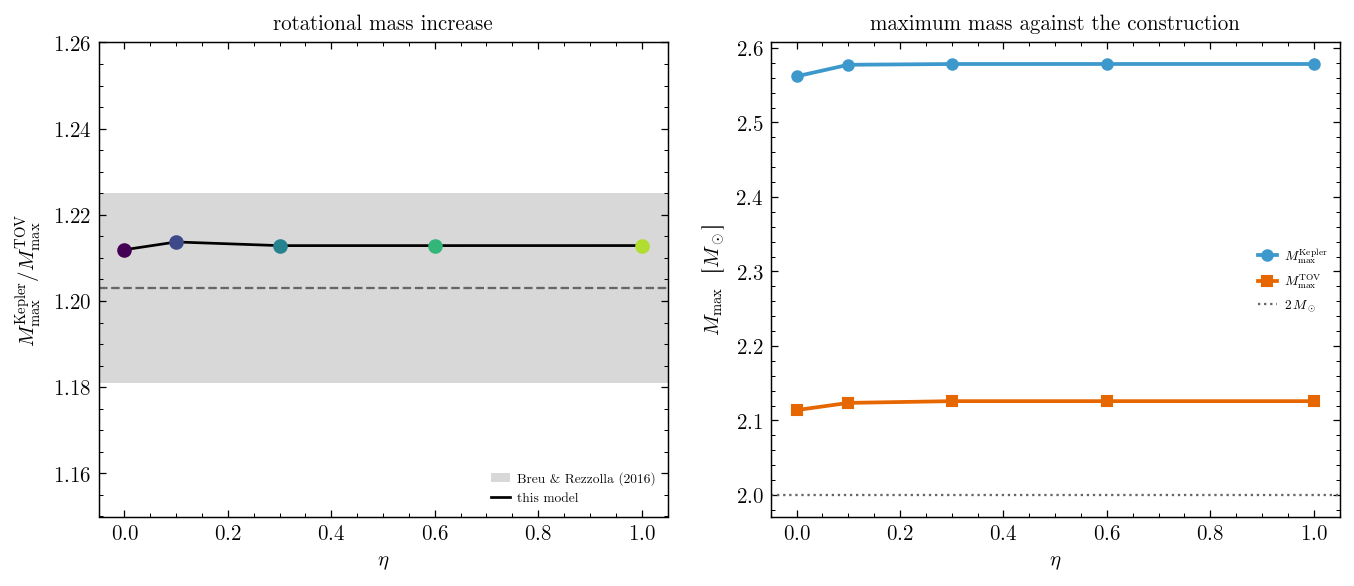

  eta    M_TOV  M_Kepler   ratio
 0.00    2.114     2.562   1.212
 0.10    2.124     2.577   1.214
 0.30    2.126     2.578   1.213
 0.60    2.126     2.578   1.213
 1.00    2.126     2.578   1.213


In [27]:
if rot_kepler:
    etas = sorted(rot_kepler)
    M_kep = np.array([np.nanmax(rot_kepler[e][:, KEPLER_COLUMNS.index("M")])
                      for e in etas])
    M_tov = np.array([tov[e]["M_max"] for e in etas])

    fig, axes = paper_grid("1x2", mode="double", placeholder=False,
                           width=FIG_WIDTH, aspect=1.2)
    axR, axM = axes[0]

    axR.axhspan(1.203 - 0.022, 1.203 + 0.022, color=STANDARD_COLORS["Gray"],
                alpha=0.25, lw=0, zorder=0, label="Breu & Rezzolla (2016)")
    axR.axhline(1.203, color=STANDARD_COLORS["Gray"], ls="--", lw=1.1, zorder=1)
    axR.plot(etas, M_kep / M_tov, "-", lw=1.3, zorder=3, color="black",
             label="this model")
    for k, eta in enumerate(etas):
        axR.plot(eta, M_kep[k] / M_tov[k], "o", ms=6, zorder=4,
                 color=COLOR_OF.get(eta, STANDARD_COLORS["Gray"]))
    axR.set_ylabel(r"$M_{\max}^{\rm Kepler} / M_{\max}^{\rm TOV}$")
    # Pinned wider than the reference band: the model values span ~0.001, so on
    # autoscale the band would fill the frame and stop reading as a band.
    axR.set_ylim(1.15, 1.26)
    axR.set_title("rotational mass increase")
    axR.legend(fontsize=6.5, loc="lower right")

    axM.plot(etas, M_kep, "-o", ms=5, color=STANDARD_COLORS["Blue"],
             label=r"$M_{\max}^{\rm Kepler}$")
    axM.plot(etas, M_tov, "-s", ms=5, color=STANDARD_COLORS["Orange"],
             label=r"$M_{\max}^{\rm TOV}$")
    axM.axhline(2.0, color=STANDARD_COLORS["Gray"], ls=":", lw=1.1,
                label=r"$2\,M_\odot$")
    axM.set_ylabel(r"$M_{\max}$  [$M_\odot$]")
    axM.set_title("maximum mass against the construction")
    axM.legend(fontsize=6.5)

    for ax in (axR, axM):
        ax.set_xlabel(r"$\eta$")
    save_figure(fig, FIG_DIR / "fig09b_kepler_ratio")
    plt.show()

    print(f"{'eta':>5} {'M_TOV':>8} {'M_Kepler':>9} {'ratio':>7}")
    for k, eta in enumerate(etas):
        print(f"{eta:5.2f} {M_tov[k]:8.3f} {M_kep[k]:9.3f} "
              f"{M_kep[k] / M_tov[k]:7.3f}")

## III.10 Quasi-universal relations

Some combinations of neutron-star observables are nearly independent of the equation of
state. That is useful — it lets one measurement stand in for another — and it is exactly
what a strong first-order phase transition is expected to spoil, because the relations
were calibrated on smooth hadronic tables. So this figure is a test of the model against
the fits, not a use of the fits.

**(a, b) C-Love.** The compactness C = GM/Rc² against the tidal deformability Λ, with the
Yagi & Yunes (2017, Phys. Rep. 681, 1) fit C = Σ a_k (ln Λ)^k, a = (0.360, −0.0355,
7.05e-4), quoted to ~6.5% over the range it was fitted on. Panel (b) is the fractional
residual, which is where a transition shows up: the fit knows nothing about a density
range where c_eq collapses.

**(c) Binary Love.** At fixed chirp mass, the symmetric and antisymmetric combinations
Λ_s = (Λ₁+Λ₂)/2 and Λ_a = (Λ₁−Λ₂)/2 trace a curve as the mass ratio varies, and that
curve is nearly EoS-independent. It is what turns a single measured Λ̃ into a constraint
on Λ(1.4). Drawn at the GW170817 chirp mass, 1.186 M_sun.

**(d) I-Love.** The dimensionless moment of inertia Ī = Ic⁴/G²M³ against Λ, with the Yagi
& Yunes fit. I comes from RNS at a slow but finite spin — there is no Hartle
slow-rotation solver in this repository — so it carries an O(Ω²) correction of order a
per cent at `ROT_F_SLOW`. Skipped entirely without RNS.

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

Saved: eos_tables_DD2vMIT/figures/fig10_universal_relations.{png, pdf}


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


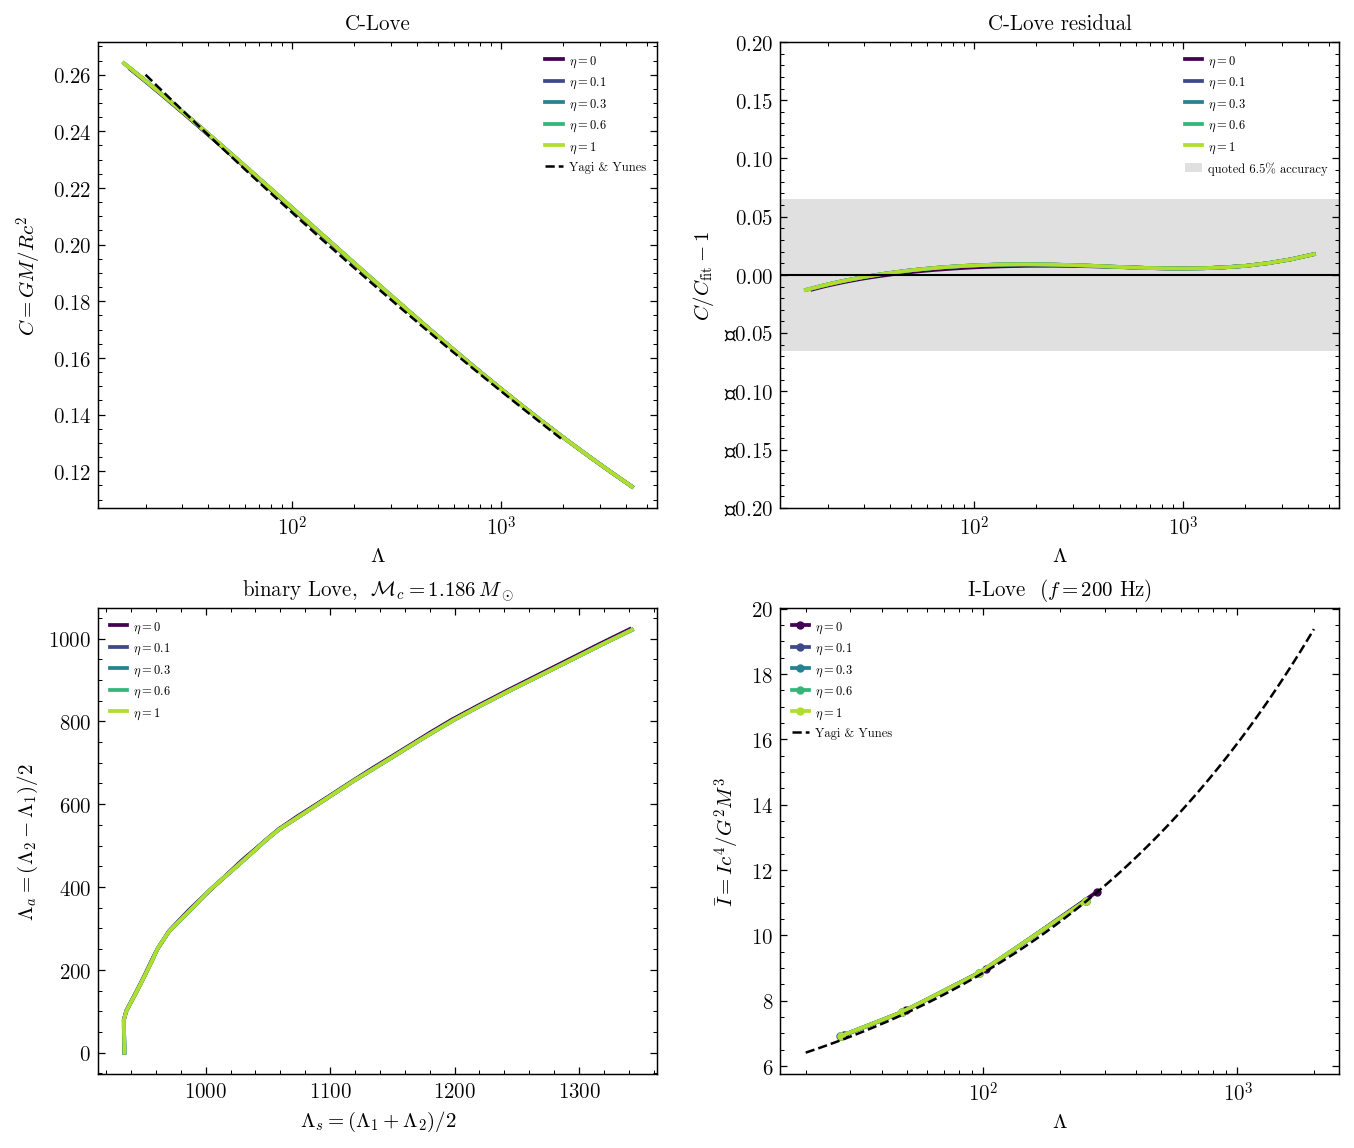

In [28]:
# Yagi & Yunes (2017), Phys. Rep. 681, 1 — the two fits used below.
C_LOVE_COEFFS = (0.360, -0.0355, 7.05e-4)                    # C = sum a_k (lnL)^k
I_LOVE_COEFFS = (1.496, 0.05951, 0.02238, -6.953e-4, 8.345e-6)  # ln I_bar
MC_GW170817 = 1.186        # chirp mass [M_sun]
Q_RANGE = np.linspace(0.7, 1.0, 40)      # mass ratio m2/m1 for panel (c)
ROT_F_SLOW = 200.0                        # Hz, the "slow" spin panel (d) uses
# The sequence runs down to ~0.1 M_sun, where Lambda passes 1e6 and no observed
# neutron star lives. Both fits were calibrated over Lambda ~ 10-5000, so
# leaving the low-mass tail in would show a huge "violation" that is only the
# fits being extrapolated four decades past their range.
M_MIN_UNIV = 1.0           # M_sun

# G M_sun / c^2 in km: turns M [M_sun] and R [km] into a dimensionless C.
KM_PER_MSUN = 1.476625
# cgs, for the dimensionless moment of inertia. RNS reports I in 1e45 g cm^2.
G_CGS, C_CGS, MSUN_G = 6.67430e-8, 2.99792458e10, 1.98892e33


def c_love_fit(Lam):
    return sum(a * np.log(Lam) ** k for k, a in enumerate(C_LOVE_COEFFS))


def i_love_fit(Lam):
    return np.exp(sum(a * np.log(Lam) ** k for k, a in enumerate(I_LOVE_COEFFS)))


def stable_branch(eta):
    """(M, R, Lambda) of one eta's static sequence, up to M_max and above
    M_MIN_UNIV — the range in which the relations below were calibrated."""
    r = tov[eta]["results"]
    i, _, _ = find_mmax_precise(r)
    M, R, Lam = r[:i + 1, 4], r[:i + 1, 3], r[:i + 1, 6]
    keep = M >= M_MIN_UNIV
    return M[keep], R[keep], Lam[keep]


fig, axes = paper_grid("2x2", mode="double", placeholder=False,
                       width=FIG_WIDTH, aspect=1.2)
axC, axRes, axBin, axI = axes.flat

for eta in sorted(tov):
    M, R, Lam = stable_branch(eta)
    ok = np.isfinite(Lam) & (Lam > 1.0)      # ln Lambda needs Lambda > 0
    if not ok.any():
        continue
    C = KM_PER_MSUN * M[ok] / R[ok]
    c = COLOR_OF.get(eta, STANDARD_COLORS["Gray"])

    axC.plot(Lam[ok], C, "-", color=c, label=rf"$\eta = {eta:g}$")
    axRes.plot(Lam[ok], C / c_love_fit(Lam[ok]) - 1.0, "-", color=c,
               label=rf"$\eta = {eta:g}$")

    # (c) binary Love at fixed chirp mass. m1 follows in closed form from
    # Mc = (m1 m2)^{3/5}/(m1+m2)^{1/5} with m2 = q m1.
    m1 = MC_GW170817 * (1.0 + Q_RANGE) ** 0.2 / Q_RANGE ** 0.6
    m2 = Q_RANGE * m1
    inside = (m1 <= M[ok].max()) & (m2 >= M[ok].min())
    if inside.any():
        L1 = np.interp(m1[inside], M[ok], Lam[ok])
        L2 = np.interp(m2[inside], M[ok], Lam[ok])
        axBin.plot((L1 + L2) / 2.0, (L2 - L1) / 2.0, "-", color=c,
                   label=rf"$\eta = {eta:g}$")

_L = np.logspace(np.log10(20.0), np.log10(2000.0), 200)
axC.plot(_L, c_love_fit(_L), "k--", lw=1.2, zorder=5, label="Yagi & Yunes")
axC.set_xscale("log")
axC.set_xlabel(r"$\Lambda$")
axC.set_ylabel(r"$C = GM/Rc^2$")
axC.set_title("C-Love")
axC.legend(fontsize=6, loc="upper right")

axRes.axhline(0.0, color="black", lw=1.0, zorder=5)
axRes.axhspan(-0.065, 0.065, color=STANDARD_COLORS["Gray"], alpha=0.20, lw=0,
              zorder=0, label="quoted 6.5% accuracy")
axRes.set_xscale("log")
axRes.set_xlabel(r"$\Lambda$")
axRes.set_ylabel(r"$C / C_{\rm fit} - 1$")
axRes.set_title("C-Love residual")
# Pinned to the scale of the quoted accuracy: on autoscale a single point at
# the very stiff end sets the range and the 6.5% band stops being visible.
axRes.set_ylim(-0.20, 0.20)
axRes.legend(fontsize=6, loc="upper right")

axBin.set_xlabel(r"$\Lambda_s = (\Lambda_1 + \Lambda_2)/2$")
axBin.set_ylabel(r"$\Lambda_a = (\Lambda_2 - \Lambda_1)/2$")
axBin.set_title(rf"binary Love,  $\mathcal{{M}}_c = {MC_GW170817:g}\,M_\odot$")
axBin.legend(fontsize=6, loc="upper left")

# (d) I-Love needs the moment of inertia, which only RNS provides here.
if have_rns():
    icol = {c: k for k, c in enumerate(GRID_COLUMNS)}
    for eta in sorted(tov):
        core = tov[eta]["core"]
        M, R, Lam = stable_branch(eta)
        # Only the stable branch: past the central density of M_max the models
        # are unstable to radial oscillations and are not stars, and including
        # them makes the curve double back on itself.
        nb_stable = ROT_NB_C[np.interp(ROT_NB_C, core.n_B, core.eps)
                             <= tov[eta]["e_c_max"]]
        if nb_stable.size < 2:
            continue
        e_c = np.interp(nb_stable, core.n_B, core.eps)
        g = rotating_grid(core.to_tov(), e_c, freq_grid=[ROT_F_SLOW],
                          n_scan=ROT_N_SCAN, parallel=True)
        M_rot, I_rot = g[:, icol["M"]], g[:, icol["I"]]
        L_at = np.interp(M_rot, M, Lam, left=np.nan, right=np.nan)
        ok = (np.isfinite(M_rot) & np.isfinite(I_rot) & np.isfinite(L_at)
              & (M_rot >= M_MIN_UNIV))
        if not ok.any():
            continue
        I_bar = (I_rot[ok] * 1e45 * C_CGS ** 4
                 / (G_CGS ** 2 * (M_rot[ok] * MSUN_G) ** 3))
        axI.plot(L_at[ok], I_bar, "-o", ms=3,
                 color=COLOR_OF.get(eta, STANDARD_COLORS["Gray"]),
                 label=rf"$\eta = {eta:g}$")
    axI.plot(_L, i_love_fit(_L), "k--", lw=1.2, zorder=5,
             label="Yagi & Yunes")
    axI.set_xscale("log")
    # I_bar spans well under a decade here, so a linear y reads better than a
    # log one whose minor ticks would be sparse.
    axI.legend(fontsize=6, loc="upper left")
else:
    axI.text(0.5, 0.5, "no RNS:\nno moment of inertia", ha="center",
             va="center", transform=axI.transAxes, fontsize=8, color="0.4")
axI.set_xlabel(r"$\Lambda$")
axI.set_ylabel(r"$\bar{I} = I c^4 / G^2 M^3$")
axI.set_title(rf"I-Love  ($f = {ROT_F_SLOW:g}$ Hz)")

save_figure(fig, FIG_DIR / "fig10_universal_relations")
plt.show()

## III.11 Parameter map — where the hybrid star lives

The II.4 scan as a picture. Colour is the onset density where a complete transition
exists; crossed cells have none. With `SCAN_TOV` on, the contour marks
M_max = 2.0 M_sun, so the region that is both hybrid *and* heavy enough to be allowed is
the coloured area on the heavy side of that line.

Saved: eos_tables_DD2vMIT/figures/fig11_parameter_map.{png, pdf}


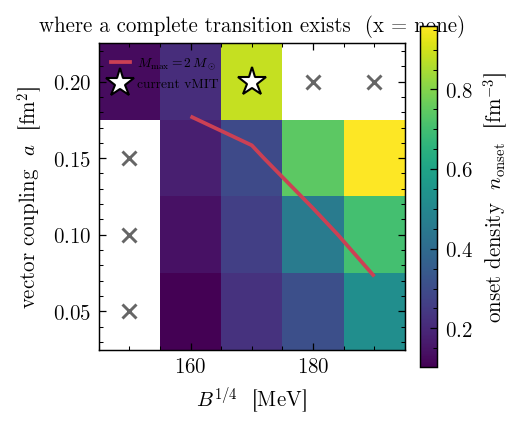

In [29]:
_B4 = np.array(sorted({r["B4"] for r in scan_rows}))
_A = np.array(sorted({r["a"] for r in scan_rows}))
_shape = (len(_A), len(_B4))
_onset = np.full(_shape, np.nan)
_mmax = np.full(_shape, np.nan)
for r in scan_rows:
    i, j = np.searchsorted(_A, r["a"]), np.searchsorted(_B4, r["B4"])
    if r["window_exists"]:
        _onset[i, j] = r["n_onset"]
    _mmax[i, j] = r.get("M_max", np.nan)

fig, axes = paper_grid("1x2", mode="centered", placeholder=False,
                       width=FIG_WIDTH * 0.6, aspect=1.0)
ax = axes[0, 0]
axes[0, 1].remove()          # one map, but paper_grid always builds a grid
# Sequential field -> viridis, per the palette convention in figure_style.
_im = ax.pcolormesh(_B4, _A, _onset, shading="nearest", cmap="viridis")
fig.colorbar(_im, ax=ax, label=r"onset density  $n_{\rm onset}$  [fm$^{-3}$]")
# Mark the combinations with no transition, which nan leaves blank.
for i, a in enumerate(_A):
    for j, b in enumerate(_B4):
        if not np.isfinite(_onset[i, j]):
            ax.plot(b, a, "x", color=STANDARD_COLORS["Gray"], ms=7, mew=1.4)
if SCAN_TOV and np.isfinite(_mmax).any():
    _red = STANDARD_COLORS["Red"]
    ax.contour(_B4, _A, _mmax, levels=[2.0], colors=[_red], linewidths=1.8)
    ax.plot([], [], "-", color=_red, lw=1.8, label=r"$M_{\max} = 2\,M_\odot$")
ax.plot(VMIT.B4, VMIT.a, "*", color="white", ms=14, mec="k", mew=1.0,
        label="current vMIT")
ax.set_xlabel(r"$B^{1/4}$  [MeV]")
ax.set_ylabel(r"vector coupling  $a$  [fm$^2$]")
ax.set_title("where a complete transition exists  (x = none)")
ax.legend(fontsize=6.5, loc="upper left")

save_figure(fig, FIG_DIR / "fig11_parameter_map")
plt.show()